In [ ]:
# ============================================================
# BLOCK 1: IMPORT LIBRARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

**This project investigates two-dimensional ground heat transport around boreholes using finite-difference numerical
simulations. The study considers thermal diffusion, groundwater advection, combined advection–diffusion transport,
time-varying heat injection, and multiple-borehole interaction**

**Pure Diffusion**

In [ ]:
# ============================================================
# BLOCK 2: PARAMETERS FROM TABLE 1
# ============================================================

# Domain size [m]
Lx = 60.0
Ly = 60.0

# Grid resolution
Nx = 200
Ny = 200

# Cell size [m]
dx = 0.3
dy = 0.3

# Time settings
dt = 0.1          # time step [s]
t_final = 10000   # total simulation time [s]

# Thermal properties
alpha = 5e-3      # thermal diffusivity [m²/s]

# Initial temperature
T0 = 10.0         # [°C]

# Constant source term (Tasks 1–3)
Q = 0.2           # [°C/s]

# Single borehole location
borehole_x = 30.0
borehole_y = 30.0

In [ ]:
# ============================================================
# BLOCK 3: GRID CREATION AND INITIAL TEMPERATURE FIELD
# ============================================================

# Create x and y coordinate arrays
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

# Create 2D mesh grid
X, Y = np.meshgrid(x, y)

# Initial temperature field
T = np.ones((Ny, Nx)) * T0

# Find nearest grid index for borehole location
i_b = np.argmin(np.abs(x - borehole_x))
j_b = np.argmin(np.abs(y - borehole_y))

print("Grid shape:", T.shape)
print("Borehole index: j =", j_b, ", i =", i_b)
print("Borehole grid location: x =", x[i_b], "m, y =", y[j_b], "m")

Grid shape: (200, 200)
Borehole index: j = 100 , i = 100
Borehole grid location: x = 30.15075376884422 m, y = 30.15075376884422 m


In [ ]:
# ============================================================
# BLOCK 4: STABILITY CHECK
# ============================================================

Fo_x = alpha * dt / dx**2
Fo_y = alpha * dt / dy**2

print("Fo_x =", Fo_x)
print("Fo_y =", Fo_y)
print("Fo_total =", Fo_x + Fo_y)

if (Fo_x + Fo_y) <= 0.5:
    print("✓ Stable simulation condition satisfied.")
else:
    print("✗ Unstable! Reduce dt or increase dx.")

Fo_x = 0.005555555555555556
Fo_y = 0.005555555555555556
Fo_total = 0.011111111111111112
✓ Stable simulation condition satisfied.


In [ ]:
# ============================================================
# BLOCK 5: TIME SETTINGS AND SAVE TIMES
# ============================================================

# Total simulation steps
n_steps = int(t_final / dt)

print("Total time steps =", n_steps)

# Times to save results
save_times = [2000, 5000, 10000]

# Convert physical times → step numbers
save_steps = [int(t/dt) for t in save_times]

print("Save times:", save_times)
print("Save step numbers:", save_steps)

# Dictionary to store results
saved_results = {}

Total time steps = 100000
Save times: [2000, 5000, 10000]
Save step numbers: [20000, 50000, 100000]


In [ ]:
# ============================================================
# BLOCK 6: MAIN PURE DIFFUSION SIMULATION LOOP
# ============================================================

for n in range(1, n_steps + 1):

    # Copy previous temperature field
    T_old = T.copy()

    # Diffusion update for internal grid cells
    T[1:-1, 1:-1] = (
        T_old[1:-1, 1:-1]
        + alpha * dt * (
            (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
            +
            (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
        )
    )

    # Add constant heat source at borehole
    T[j_b, i_b] += Q * dt

    # No-flux boundary condition
    T[0, :] = T[1, :]
    T[-1, :] = T[-2, :]
    T[:, 0] = T[:, 1]
    T[:, -1] = T[:, -2]

    # Save results at selected times
    if n in save_steps:
        saved_results[n * dt] = T.copy()
        print(f"Saved result at t = {n*dt:.0f} s")

print("Task 1 pure diffusion simulation finished.")

Saved result at t = 2000 s
Saved result at t = 5000 s
Saved result at t = 10000 s
Task 1 pure diffusion simulation finished.



**Temperature Field at Different Times**


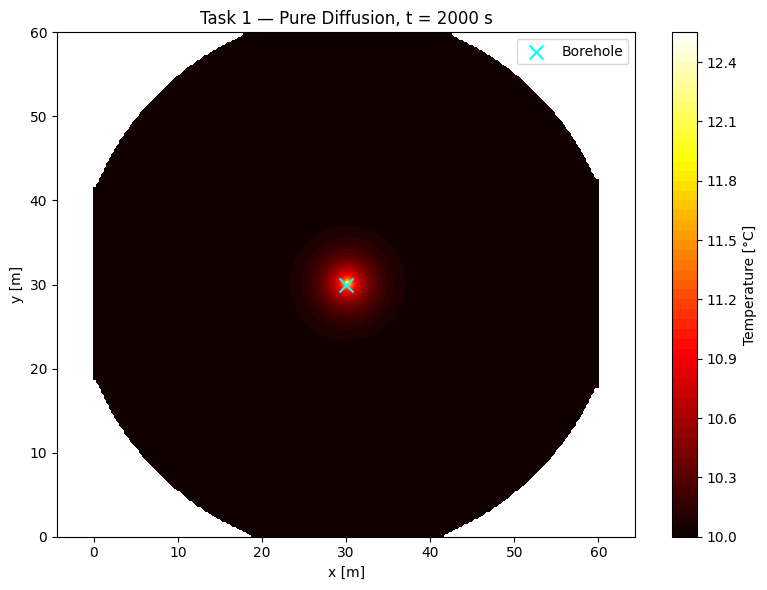

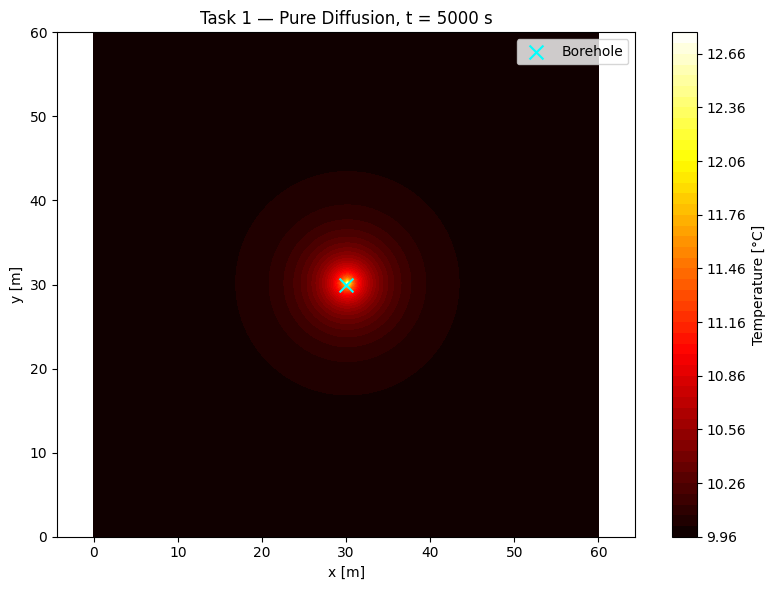

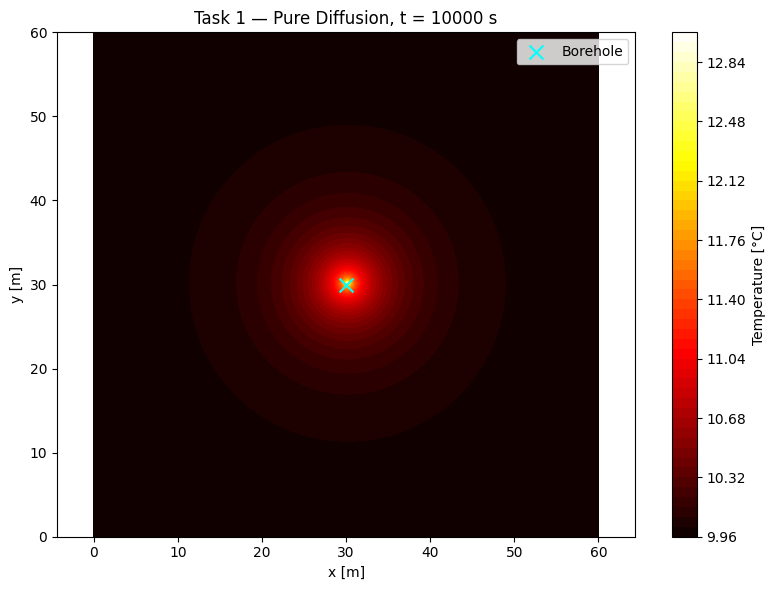

In [ ]:
# ============================================================
# BLOCK 7: PLOT TEMPERATURE FIELDS
# ============================================================

for time, T_plot in saved_results.items():

    plt.figure(figsize=(8,6))

    contour = plt.contourf(
        X, Y, T_plot,
        levels=50,
        cmap='hot'
    )

    plt.colorbar(contour, label='Temperature [°C]')

    plt.scatter(
        borehole_x,
        borehole_y,
        color='cyan',
        marker='x',
        s=100,
        label='Borehole'
    )

    plt.xlabel('x [m]')
    plt.ylabel('y [m]')

    plt.title(f'Task 1 — Pure Diffusion, t = {time:.0f} s')

    plt.axis('equal')
    plt.legend()
    plt.tight_layout()

    plt.show()


**Comparison with Analytical Diffusion Length**

In [ ]:
# ============================================================
# BLOCK 8: ANALYTICAL DIFFUSION LENGTH
# ============================================================

print("\nAnalytical diffusion length comparison:\n")

for t in save_times:

    L = np.sqrt(4 * alpha * t)

    print(f"t = {t:5d} s   -->   L(t) = {L:.2f} m")


Analytical diffusion length comparison:

t =  2000 s   -->   L(t) = 6.32 m
t =  5000 s   -->   L(t) = 10.00 m
t = 10000 s   -->   L(t) = 14.14 m


**Effect of Increasing Thermal Diffusivity**




In [ ]:
# ============================================================
# BLOCK 9: EFFECT OF INCREASING THERMAL DIFFUSIVITY α
# ============================================================

alpha_values = [5e-3, 1e-2, 2e-2]

comparison_results = {}

for alpha_test in alpha_values:

    # reset temperature field
    T_alpha = np.ones((Ny, Nx)) * T0

    for n in range(n_steps):

        T_old = T_alpha.copy()

        # diffusion update
        T_alpha[1:-1,1:-1] = (

            T_old[1:-1,1:-1]

            + alpha_test*dt*(

                (T_old[1:-1,2:] - 2*T_old[1:-1,1:-1] + T_old[1:-1,:-2])/dx**2

                +

                (T_old[2:,1:-1] - 2*T_old[1:-1,1:-1] + T_old[:-2,1:-1])/dy**2
            )
        )

        # heat source
        T_alpha[j_b,i_b] += Q*dt

        # no-flux BC
        T_alpha[0,:] = T_alpha[1,:]
        T_alpha[-1,:] = T_alpha[-2,:]
        T_alpha[:,0] = T_alpha[:,1]
        T_alpha[:,-1] = T_alpha[:,-2]

    comparison_results[alpha_test] = T_alpha.copy()

print("Alpha study completed.")

Alpha study completed.


/tmp/ipykernel_14858/2411625378.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


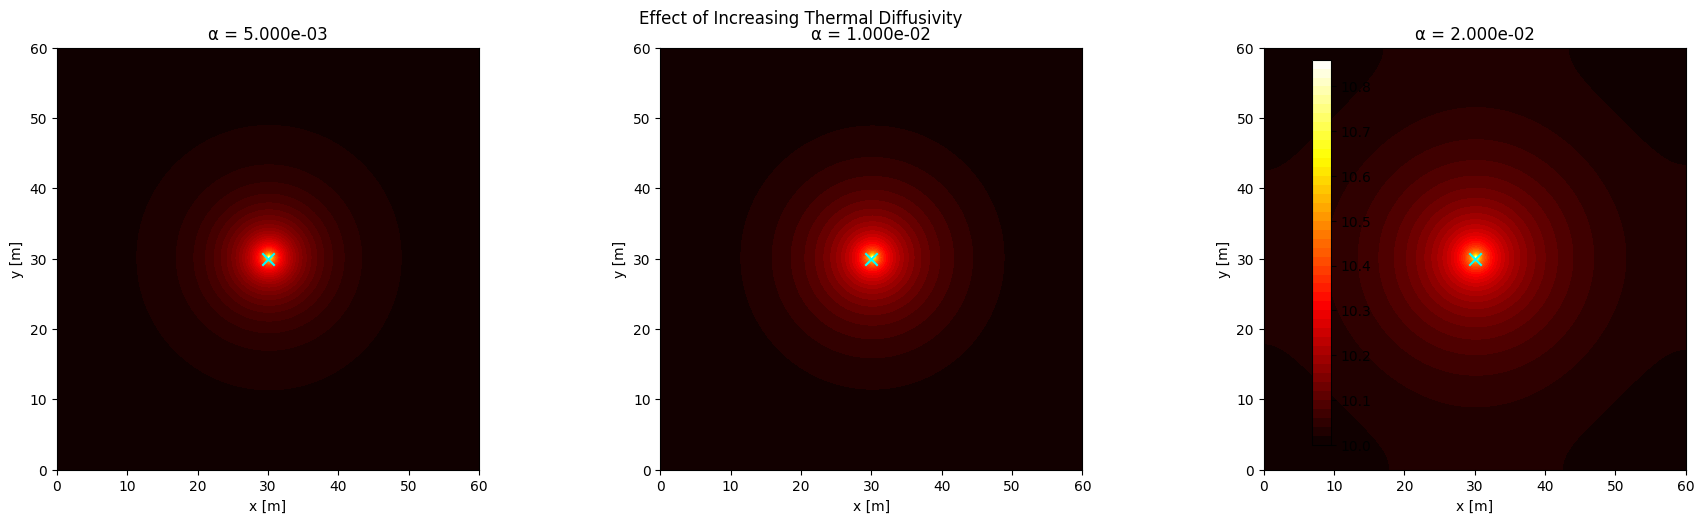

In [ ]:
# ============================================================
# BLOCK 10: PLOT EFFECT OF THERMAL DIFFUSIVITY α
# ============================================================

fig, axes = plt.subplots(1,3, figsize=(18,5))

for ax, alpha_test in zip(axes, alpha_values):

    T_plot = comparison_results[alpha_test]

    contour = ax.contourf(
        X,
        Y,
        T_plot,
        levels=50,
        cmap='hot'
    )

    ax.scatter(
        borehole_x,
        borehole_y,
        color='cyan',
        marker='x',
        s=80
    )

    ax.set_title(f'α = {alpha_test:.3e}')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_aspect('equal')

fig.colorbar(contour, ax=axes.ravel().tolist())

plt.suptitle('Effect of Increasing Thermal Diffusivity')

plt.tight_layout()

plt.show()

**Effect of Increasing or Decreasing Source Strength**

In [ ]:
# ============================================================
# BLOCK 11: EFFECT OF SOURCE STRENGTH Q
# ============================================================

Q_values = [0.1, 0.2, 0.4]

Q_comparison_results = {}

for Q_test in Q_values:

    # reset temperature field
    T_Q = np.ones((Ny, Nx)) * T0

    for n in range(n_steps):

        T_old = T_Q.copy()

        # diffusion update
        T_Q[1:-1, 1:-1] = (
            T_old[1:-1, 1:-1]
            + alpha * dt * (
                (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
                +
                (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
            )
        )

        # source strength test
        T_Q[j_b, i_b] += Q_test * dt

        # no-flux boundary condition
        T_Q[0, :] = T_Q[1, :]
        T_Q[-1, :] = T_Q[-2, :]
        T_Q[:, 0] = T_Q[:, 1]
        T_Q[:, -1] = T_Q[:, -2]

    Q_comparison_results[Q_test] = T_Q.copy()

print("Q source strength study completed.")

Q source strength study completed.


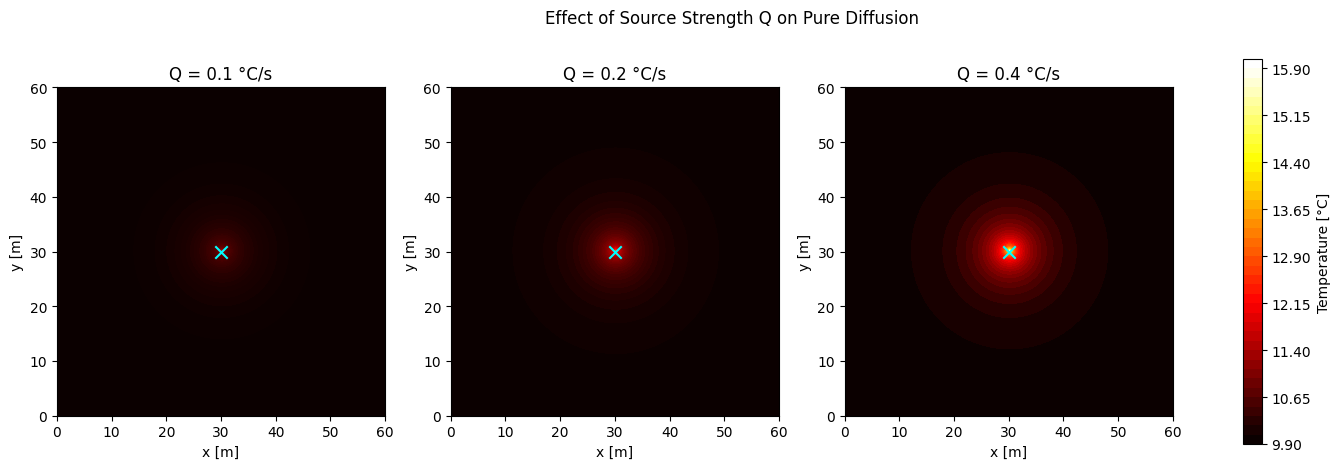

In [ ]:
# ============================================================
# BLOCK 12: PLOT EFFECT OF SOURCE STRENGTH Q
# ============================================================

vmin = min(np.min(T) for T in Q_comparison_results.values())
vmax = max(np.max(T) for T in Q_comparison_results.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, Q_test in zip(axes, Q_values):

    T_plot = Q_comparison_results[Q_test]

    contour = ax.contourf(
        X, Y, T_plot,
        levels=50,
        cmap='hot',
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(
        borehole_x,
        borehole_y,
        color='cyan',
        marker='x',
        s=80
    )

    ax.set_title(f'Q = {Q_test:.1f} °C/s')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_aspect('equal')

fig.colorbar(contour, ax=axes.ravel().tolist(), label='Temperature [°C]')
plt.suptitle('Effect of Source Strength Q on Pure Diffusion')
plt.show()

When Q is increased, the borehole injects more heat per unit time. Therefore, the maximum temperature near the borehole increases and the thermal plume becomes more intense. The plume radius may appear slightly larger because more surrounding soil reaches elevated temperature levels, but the spreading rate is still mainly controlled by α, not Q.

When Q is decreased, the heat input becomes weaker. The temperature rise above T
0
	​

 is smaller, the hotspot is less intense, and the plume becomes less visible.

Summer/winter analogy:

In winter, a borehole heat pump may operate with stronger heating demand, so the heat extraction/injection effect becomes larger. This is similar to a higher absolute source strength Q, producing a stronger thermal disturbance around the borehole.

In summer, the heating demand is lower or the borehole may operate in cooling/recharging mode. This corresponds to a lower Q, or sometimes even an opposite-sign Q, giving a weaker or reversed temperature disturbance.

**Numerical Detection of Plume Radius**


In [ ]:
# ============================================================
# BLOCK 13: NUMERICAL PLUME RADIUS DETECTION
# ============================================================

threshold = 0.01   # °C

plume_radius_results = []

# distance of every grid cell from borehole
R = np.sqrt((X - borehole_x)**2 + (Y - borehole_y)**2)

for time, T_plot in saved_results.items():

    # temperature rise above initial temperature
    delta_T = T_plot - T0

    # cells where plume is still detectable
    plume_mask = delta_T >= threshold

    # numerical plume radius = maximum radial distance where delta_T >= threshold
    numerical_radius = np.max(R[plume_mask])

    # analytical diffusion length
    analytical_radius = np.sqrt(4 * alpha * time)

    plume_radius_results.append({
        "time_s": time,
        "numerical_radius_m": numerical_radius,
        "analytical_L_m": analytical_radius,
        "difference_m": numerical_radius - analytical_radius
    })

# print result table
for row in plume_radius_results:
    print(
        f"t = {row['time_s']:7.0f} s | "
        f"Numerical radius = {row['numerical_radius_m']:6.2f} m | "
        f"Analytical L(t) = {row['analytical_L_m']:6.2f} m | "
        f"Difference = {row['difference_m']:6.2f} m"
    )

t =    2000 s | Numerical radius =   9.70 m | Analytical L(t) =   6.32 m | Difference =   3.37 m
t =    5000 s | Numerical radius =  15.26 m | Analytical L(t) =  10.00 m | Difference =   5.26 m
t =   10000 s | Numerical radius =  21.51 m | Analytical L(t) =  14.14 m | Difference =   7.37 m


The numerical plume radius increased from 9.70 m at 2000 s to 15.26 m at 5000 s and 21.51 m at 10000 s. The analytical diffusion length predicted smaller characteristic distances of 6.32 m, 10.00 m and 14.14 m, respectively. The numerical radius is larger because the plume boundary was defined using a low temperature threshold of 0.01 °C. Therefore, weak diffusive temperature changes beyond the characteristic diffusion length are still included in the numerical plume. However, both methods show the same trend: the plume radius increases with time.

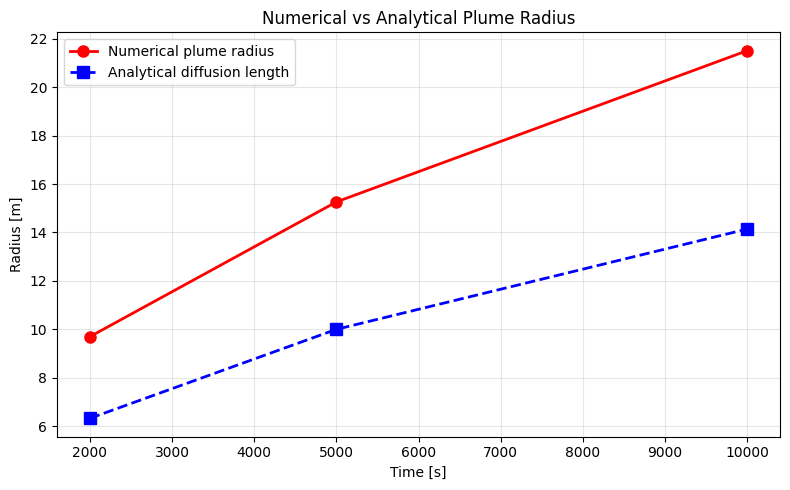

In [ ]:
# ============================================================
# BLOCK 14: PLOT NUMERICAL VS ANALYTICAL PLUME RADIUS
# ============================================================

times = [row["time_s"] for row in plume_radius_results]

numerical = [row["numerical_radius_m"] for row in plume_radius_results]

analytical = [row["analytical_L_m"] for row in plume_radius_results]

plt.figure(figsize=(8,5))

plt.plot(
    times,
    numerical,
    'o-r',
    linewidth=2,
    markersize=8,
    label='Numerical plume radius'
)

plt.plot(
    times,
    analytical,
    's--b',
    linewidth=2,
    markersize=8,
    label='Analytical diffusion length'
)

plt.xlabel('Time [s]')
plt.ylabel('Radius [m]')

plt.title('Numerical vs Analytical Plume Radius')

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

**Grid Refinement Study**


In [ ]:
# ============================================================
# BLOCK 15: GRID REFINEMENT STUDY
# ============================================================

grid_sizes = [100, 200, 400]
grid_results = {}

t_refine = 2000   # seconds

for N in grid_sizes:

    print(f"Running grid size {N} x {N} ...")

    # grid
    x_g = np.linspace(0, Lx, N)
    y_g = np.linspace(0, Ly, N)
    X_g, Y_g = np.meshgrid(x_g, y_g)

    dx_g = x_g[1] - x_g[0]
    dy_g = y_g[1] - y_g[0]

    # temperature field
    T_g = np.ones((N, N)) * T0

    # borehole index
    i_bg = np.argmin(np.abs(x_g - borehole_x))
    j_bg = np.argmin(np.abs(y_g - borehole_y))

    # stability check
    Fo_total_g = alpha * dt / dx_g**2 + alpha * dt / dy_g**2
    print("Fo_total =", Fo_total_g)

    n_steps_g = int(t_refine / dt)

    for n in range(n_steps_g):

        T_old = T_g.copy()

        T_g[1:-1, 1:-1] = (
            T_old[1:-1, 1:-1]
            + alpha * dt * (
                (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx_g**2
                +
                (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy_g**2
            )
        )

        T_g[j_bg, i_bg] += Q * dt

        # no-flux boundary condition
        T_g[0, :] = T_g[1, :]
        T_g[-1, :] = T_g[-2, :]
        T_g[:, 0] = T_g[:, 1]
        T_g[:, -1] = T_g[:, -2]

    grid_results[N] = {
        "x": x_g,
        "y": y_g,
        "X": X_g,
        "Y": Y_g,
        "T": T_g,
        "dx": dx_g,
        "dy": dy_g
    }

print("Grid refinement study completed.")

Running grid size 100 x 100 ...
Fo_total = 0.0027224999999999997
Running grid size 200 x 200 ...
Fo_total = 0.011000277777777779
Running grid size 400 x 400 ...
Fo_total = 0.044222500000000005
Grid refinement study completed.


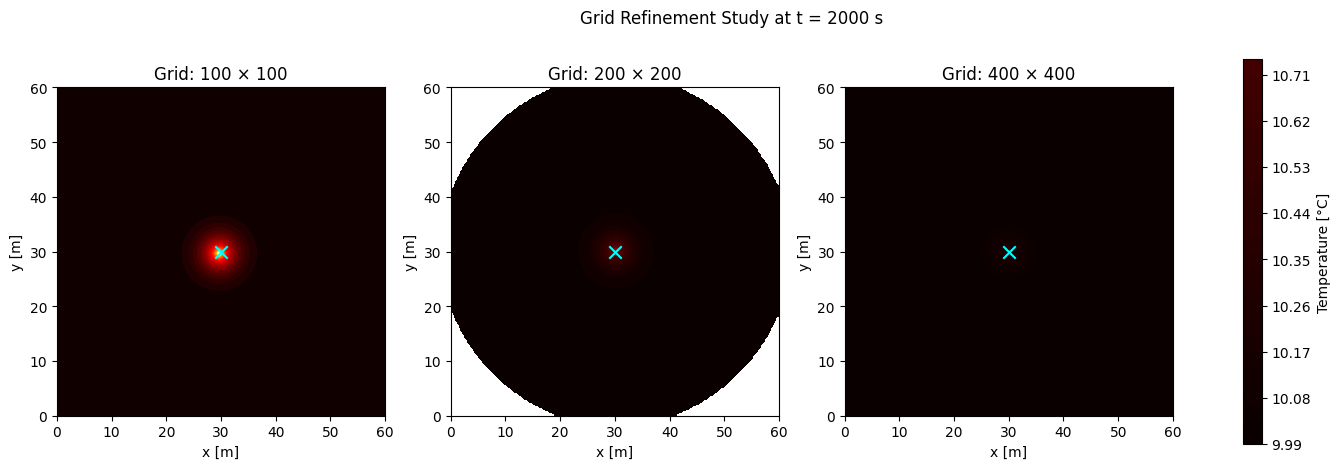

In [ ]:
# ============================================================
# BLOCK 16: PLOT GRID REFINEMENT RESULTS
# ============================================================

vmin = min(np.min(grid_results[N]["T"]) for N in grid_sizes)
vmax = max(np.max(grid_results[N]["T"]) for N in grid_sizes)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, N in zip(axes, grid_sizes):

    result = grid_results[N]

    contour = ax.contourf(
        result["X"],
        result["Y"],
        result["T"],
        levels=50,
        cmap="hot",
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(
        borehole_x,
        borehole_y,
        color="cyan",
        marker="x",
        s=80
    )

    ax.set_title(f"Grid: {N} × {N}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(contour, ax=axes.ravel().tolist(), label="Temperature [°C]")

plt.suptitle(f"Grid Refinement Study at t = {t_refine} s")
plt.show()

In [ ]:
# ============================================================
# BLOCK 15–16: GRID REFINEMENT STUDY
# 100×100, 200×200, 400×400
# Compare at t = 2000 s and 10000 s
# ============================================================

grid_sizes = [100,200,400]
study_times = [2000,10000]

grid_results = {}

for N in grid_sizes:

    print(f"\nRunning grid {N} × {N}")

    # ----- grid -----
    x_g = np.linspace(0,Lx,N)
    y_g = np.linspace(0,Ly,N)

    X_g,Y_g = np.meshgrid(x_g,y_g)

    dx_g = x_g[1]-x_g[0]
    dy_g = y_g[1]-y_g[0]

    # ----- stability -----
    Fo_total = alpha*dt/dx_g**2 + alpha*dt/dy_g**2

    print("Fo_total =",Fo_total)

    # ----- temperature field -----
    T_g = np.ones((N,N))*T0

    # borehole index
    i_bg = np.argmin(np.abs(x_g-borehole_x))
    j_bg = np.argmin(np.abs(y_g-borehole_y))

    n_steps = int(t_final/dt)

    save_steps = [int(t/dt) for t in study_times]

    grid_results[N] = {}

    # ----- main loop -----
    for n in range(1,n_steps+1):

        T_old = T_g.copy()

        # diffusion update
        T_g[1:-1,1:-1] = (

            T_old[1:-1,1:-1]

            + alpha*dt*(

                (T_old[1:-1,2:]
                -2*T_old[1:-1,1:-1]
                +T_old[1:-1,:-2])/dx_g**2

                +

                (T_old[2:,1:-1]
                -2*T_old[1:-1,1:-1]
                +T_old[:-2,1:-1])/dy_g**2
            )
        )

        # source
        T_g[j_bg,i_bg] += Q*dt

        # no-flux BC
        T_g[0,:] = T_g[1,:]
        T_g[-1,:] = T_g[-2,:]
        T_g[:,0] = T_g[:,1]
        T_g[:,-1] = T_g[:,-2]

        # save snapshots
        if n in save_steps:

            grid_results[N][n*dt] = {

                "X":X_g,
                "Y":Y_g,
                "T":T_g.copy()
            }

print("\nGrid refinement simulation completed.")


Running grid 100 × 100
Fo_total = 0.0027224999999999997

Running grid 200 × 200
Fo_total = 0.011000277777777779

Running grid 400 × 400
Fo_total = 0.044222500000000005

Grid refinement simulation completed.


**Time-Step Convergence Test**

In [ ]:
# ============================================================
# BLOCK 17: TIME-STEP CONVERGENCE TEST
# Compare dt = 0.1, 0.05, 0.02 s
# ============================================================

dt_values = [0.1, 0.05, 0.02]
t_compare = 2000     # compare at 2000 s

timestep_results = {}

for dt_test in dt_values:

    print(f"\nRunning simulation for Δt = {dt_test} s")

    # Reset temperature field
    T_dt = np.ones((Ny, Nx)) * T0

    # Stability check
    Fo_total = alpha * dt_test / dx**2 + alpha * dt_test / dy**2
    print("Fo_total =", Fo_total)

    if Fo_total > 0.5:
        print("WARNING: unstable time step!")

    # Number of time steps
    n_steps_dt = int(t_compare / dt_test)

    # Time loop
    for n in range(n_steps_dt):

        T_old = T_dt.copy()

        # Diffusion update
        T_dt[1:-1, 1:-1] = (
            T_old[1:-1, 1:-1]
            + alpha * dt_test * (
                (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
                +
                (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
            )
        )

        # Constant borehole source
        T_dt[j_b, i_b] += Q * dt_test

        # No-flux boundary condition
        T_dt[0, :] = T_dt[1, :]
        T_dt[-1, :] = T_dt[-2, :]
        T_dt[:, 0] = T_dt[:, 1]
        T_dt[:, -1] = T_dt[:, -2]

    timestep_results[dt_test] = T_dt.copy()

print("\nTime-step convergence test completed.")


Running simulation for Δt = 0.1 s
Fo_total = 0.011111111111111112

Running simulation for Δt = 0.05 s
Fo_total = 0.005555555555555556

Running simulation for Δt = 0.02 s
Fo_total = 0.0022222222222222222

Time-step convergence test completed.


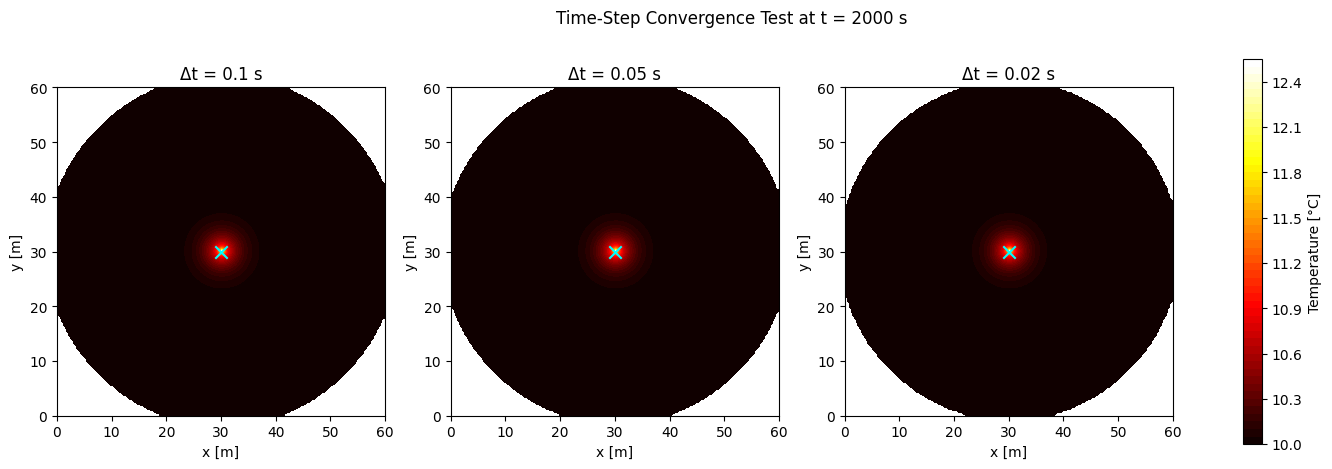

In [ ]:
# ============================================================
# BLOCK 18: PLOT TIME-STEP CONVERGENCE
# ============================================================

vmin = min(np.min(T) for T in timestep_results.values())
vmax = max(np.max(T) for T in timestep_results.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, dt_test in zip(axes, dt_values):

    T_plot = timestep_results[dt_test]

    contour = ax.contourf(
        X, Y, T_plot,
        levels=50,
        cmap="hot",
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(borehole_x, borehole_y, color="cyan", marker="x", s=80)

    ax.set_title(f"Δt = {dt_test} s")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(contour, ax=axes.ravel().tolist(), label="Temperature [°C]")
plt.suptitle(f"Time-Step Convergence Test at t = {t_compare} s")
plt.show()

In [ ]:
# ============================================================
# BLOCK 19: ERROR AGAINST FINEST TIME STEP
# Reference: dt = 0.02 s
# ============================================================

T_ref = timestep_results[0.02]

for dt_test in dt_values:

    T_test = timestep_results[dt_test]

    rmse = np.sqrt(np.mean((T_test - T_ref)**2))
    max_error = np.max(np.abs(T_test - T_ref))

    print(
        f"Δt = {dt_test:5.2f} s | "
        f"RMSE = {rmse:.6e} °C | "
        f"Max error = {max_error:.6e} °C"
    )

Δt =  0.10 s | RMSE = 5.356980e-07 °C | Max error = 5.742466e-06 °C
Δt =  0.05 s | RMSE = 2.008855e-07 °C | Max error = 2.153434e-06 °C
Δt =  0.02 s | RMSE = 0.000000e+00 °C | Max error = 0.000000e+00 °C


**Pure Advection**

In [ ]:
# ============================================================
# BLOCK 1: SELECT GROUP
# ============================================================

group = 1   # change this to your group number: 1, 2, 3, 4, 5, or 6

In [ ]:
# ============================================================
# TASK 2 — BLOCK 1: GROUP SELECTION
# ============================================================

group = 3

print("Selected group:", group)
print("Using Group 3 velocity field:")
print("vx = -0.02(y - 40)")
print("vy =  0.02(x - 40)")

Selected group: 3
Using Group 3 velocity field:
vx = -0.02(y - 40)
vy =  0.02(x - 40)


In [ ]:
# ============================================================
# TASK 2 — BLOCK 2: DEFINE GROUP 3 VELOCITY FIELD
# ============================================================

vx = -0.02 * (Y - 40)

vy = 0.02 * (X - 40)

print("Velocity field created.")

print("vx min =", np.min(vx))
print("vx max =", np.max(vx))

print("vy min =", np.min(vy))
print("vy max =", np.max(vy))

Velocity field created.
vx min = -0.4
vx max = 0.8
vy min = -0.8
vy max = 0.4


**Velocity Field**

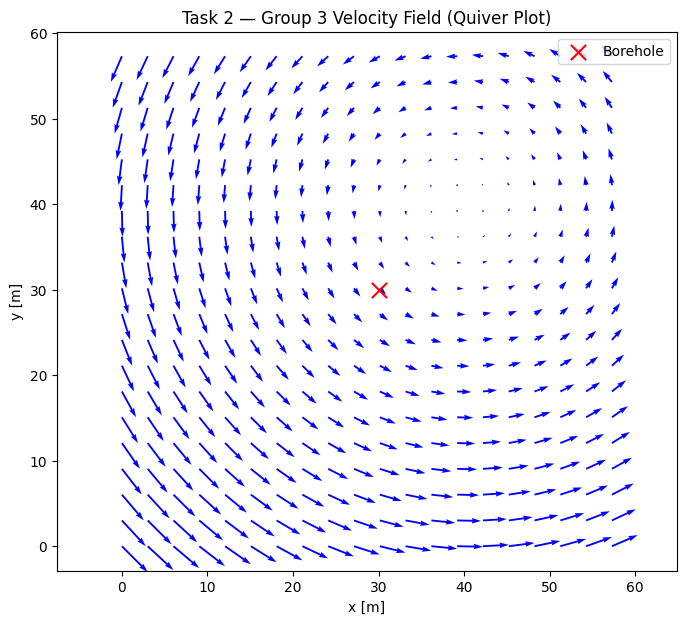

In [ ]:
# ============================================================
# TASK 2 — BLOCK 3: QUVER PLOT OF VELOCITY FIELD
# ============================================================

plt.figure(figsize=(8,7))

# use fewer arrows for cleaner visualization
skip = 10

plt.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    vx[::skip, ::skip],
    vy[::skip, ::skip],
    color='blue'
)

# Borehole location
plt.scatter(
    borehole_x,
    borehole_y,
    color='red',
    marker='x',
    s=120,
    label='Borehole'
)

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.title('Task 2 — Group 3 Velocity Field (Quiver Plot)')

plt.axis('equal')
plt.legend()

plt.show()

**Plume Trajectory and Directional Behaviour**

In [ ]:
# ============================================================
# TASK 2 — BLOCK 4: PURE ADVECTION SOLVER
# Group 3, single borehole, constant Q
# ============================================================

# Reset temperature field
T_adv = np.ones((Ny, Nx)) * T0

# Save times
adv_save_times = [2000, 5000, 10000]
adv_save_steps = [int(t / dt) for t in adv_save_times]

adv_results = {}
plume_centers = []

# CFL check
CFL_x = np.max(np.abs(vx)) * dt / dx
CFL_y = np.max(np.abs(vy)) * dt / dy

print("CFL_x =", CFL_x)
print("CFL_y =", CFL_y)
print("CFL_total =", CFL_x + CFL_y)

if CFL_x + CFL_y <= 1:
    print("✓ CFL condition approximately satisfied.")
else:
    print("⚠ CFL condition may be unstable. Reduce dt.")

# Main time loop
for n in range(1, n_steps + 1):

    T_old = T_adv.copy()

    # Upwind derivatives
    dTdx = np.zeros_like(T_adv)
    dTdy = np.zeros_like(T_adv)

    # x-direction upwind
    dTdx[:, 1:-1] = np.where(
        vx[:, 1:-1] > 0,
        (T_old[:, 1:-1] - T_old[:, :-2]) / dx,
        (T_old[:, 2:] - T_old[:, 1:-1]) / dx
    )

    # y-direction upwind
    dTdy[1:-1, :] = np.where(
        vy[1:-1, :] > 0,
        (T_old[1:-1, :] - T_old[:-2, :]) / dy,
        (T_old[2:, :] - T_old[1:-1, :]) / dy
    )

    # Pure advection update
    T_adv = T_old - dt * (vx * dTdx + vy * dTdy)

    # Add constant source at borehole
    T_adv[j_b, i_b] += Q * dt

    # No-gradient boundary condition
    T_adv[0, :] = T_adv[1, :]
    T_adv[-1, :] = T_adv[-2, :]
    T_adv[:, 0] = T_adv[:, 1]
    T_adv[:, -1] = T_adv[:, -2]

    # Track plume center using temperature excess
    delta_T = T_adv - T0
    delta_T[delta_T < 0] = 0

    total_heat = np.sum(delta_T)

    if total_heat > 0:
        xc = np.sum(X * delta_T) / total_heat
        yc = np.sum(Y * delta_T) / total_heat
        plume_centers.append((n * dt, xc, yc))

    # Save snapshots
    if n in adv_save_steps:
        adv_results[n * dt] = T_adv.copy()
        print(f"Saved advection result at t = {n*dt:.0f} s")

print("Pure advection simulation finished.")

CFL_x = 0.2666666666666667
CFL_y = 0.2666666666666667
CFL_total = 0.5333333333333334
✓ CFL condition approximately satisfied.
Saved advection result at t = 2000 s
Saved advection result at t = 5000 s
Saved advection result at t = 10000 s
Pure advection simulation finished.


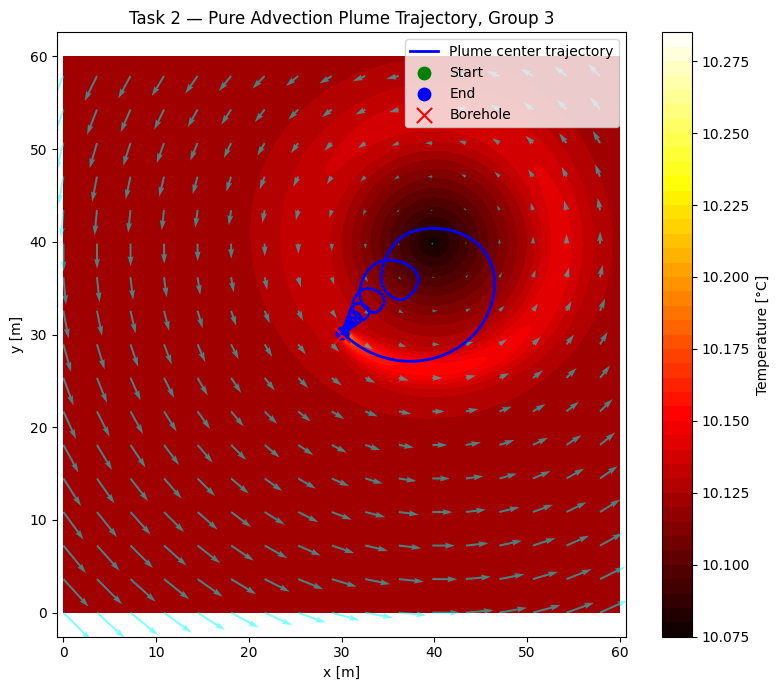

In [ ]:
# ============================================================
# TASK 2 — BLOCK 5: PLOT PLUME TRAJECTORY
# ============================================================

plt.figure(figsize=(8, 7))

# final temperature field
final_time = adv_save_times[-1]
T_final_adv = adv_results[final_time]

contour = plt.contourf(
    X, Y, T_final_adv,
    levels=50,
    cmap="hot"
)

plt.colorbar(contour, label="Temperature [°C]")

# velocity field
skip = 12
plt.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    vx[::skip, ::skip],
    vy[::skip, ::skip],
    color="cyan",
    alpha=0.5
)

# plume center trajectory
plume_centers_array = np.array(plume_centers)

plt.plot(
    plume_centers_array[:, 1],
    plume_centers_array[:, 2],
    "b-",
    linewidth=2,
    label="Plume center trajectory"
)

plt.scatter(
    plume_centers_array[0, 1],
    plume_centers_array[0, 2],
    color="green",
    s=80,
    label="Start"
)

plt.scatter(
    plume_centers_array[-1, 1],
    plume_centers_array[-1, 2],
    color="blue",
    s=80,
    label="End"
)

plt.scatter(
    borehole_x,
    borehole_y,
    color="red",
    marker="x",
    s=120,
    label="Borehole"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Task 2 — Pure Advection Plume Trajectory, Group 3")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

**Effect of Increasing Time Step**

In [ ]:
# ============================================================
# TASK 2 — TIME STEP EFFECT FOR PURE ADVECTION
# Compare dt = 0.1, 0.2, 0.5 s
# ============================================================

dt_adv_values = [0.1, 0.2, 0.5]
t_compare_adv = 2000

adv_dt_results = {}
adv_dt_centers = {}

for dt_test in dt_adv_values:

    print(f"\nRunning pure advection with dt = {dt_test} s")

    T_test = np.ones((Ny, Nx)) * T0
    centers = []

    CFL_x = np.max(np.abs(vx)) * dt_test / dx
    CFL_y = np.max(np.abs(vy)) * dt_test / dy
    CFL_total = CFL_x + CFL_y

    print("CFL_total =", CFL_total)

    n_steps_test = int(t_compare_adv / dt_test)

    for n in range(1, n_steps_test + 1):

        T_old = T_test.copy()

        dTdx = np.zeros_like(T_test)
        dTdy = np.zeros_like(T_test)

        dTdx[:, 1:-1] = np.where(
            vx[:, 1:-1] > 0,
            (T_old[:, 1:-1] - T_old[:, :-2]) / dx,
            (T_old[:, 2:] - T_old[:, 1:-1]) / dx
        )

        dTdy[1:-1, :] = np.where(
            vy[1:-1, :] > 0,
            (T_old[1:-1, :] - T_old[:-2, :]) / dy,
            (T_old[2:, :] - T_old[1:-1, :]) / dy
        )

        T_test = T_old - dt_test * (vx * dTdx + vy * dTdy)

        # constant source
        T_test[j_b, i_b] += Q * dt_test

        # boundary condition
        T_test[0, :] = T_test[1, :]
        T_test[-1, :] = T_test[-2, :]
        T_test[:, 0] = T_test[:, 1]
        T_test[:, -1] = T_test[:, -2]

        # plume center
        delta_T = T_test - T0
        delta_T[delta_T < 0] = 0

        total_heat = np.sum(delta_T)

        if total_heat > 0:
            xc = np.sum(X * delta_T) / total_heat
            yc = np.sum(Y * delta_T) / total_heat
            centers.append((n * dt_test, xc, yc))

    adv_dt_results[dt_test] = T_test.copy()
    adv_dt_centers[dt_test] = np.array(centers)

print("\nTask 2 time-step effect completed.")


Running pure advection with dt = 0.1 s
CFL_total = 0.5333333333333334

Running pure advection with dt = 0.2 s
CFL_total = 1.0666666666666669

Running pure advection with dt = 0.5 s
CFL_total = 2.666666666666667


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_14858/1327595078.py:64: RuntimeWarning: overflow encountered in multiply
  xc = np.sum(X * delta_T) / total_heat
/tmp/ipykernel_14858/1327595078.py:64: RuntimeWarning: invalid value encountered in scalar divide
  xc = np.sum(X * delta_T) / total_heat
/tmp/ipykernel_14858/1327595078.py:65: RuntimeWarning: invalid value encountered in scalar divide
  yc = np.sum(Y * delta_T) / total_heat
/tmp/ipykernel_14858/1327595078.py:65: RuntimeWarning: overflow encountered in multiply
  yc = np.sum(Y * delta_T) / total_heat
/tmp/ipykernel_14858/1327595078.py:42: RuntimeWarning: overflow encountered in divide
  (T_old[1:-1, :] - T_old[:-2, :]) / dy,
/tmp/ipykernel_14858/1327595078.py:43: RuntimeWarning: overflow encountered in divide
  (T_old[2:, :] - T_old[1:-1, :]) / dy
/tmp/ipykernel_14858/1327595078.py:36: 


Task 2 time-step effect completed.


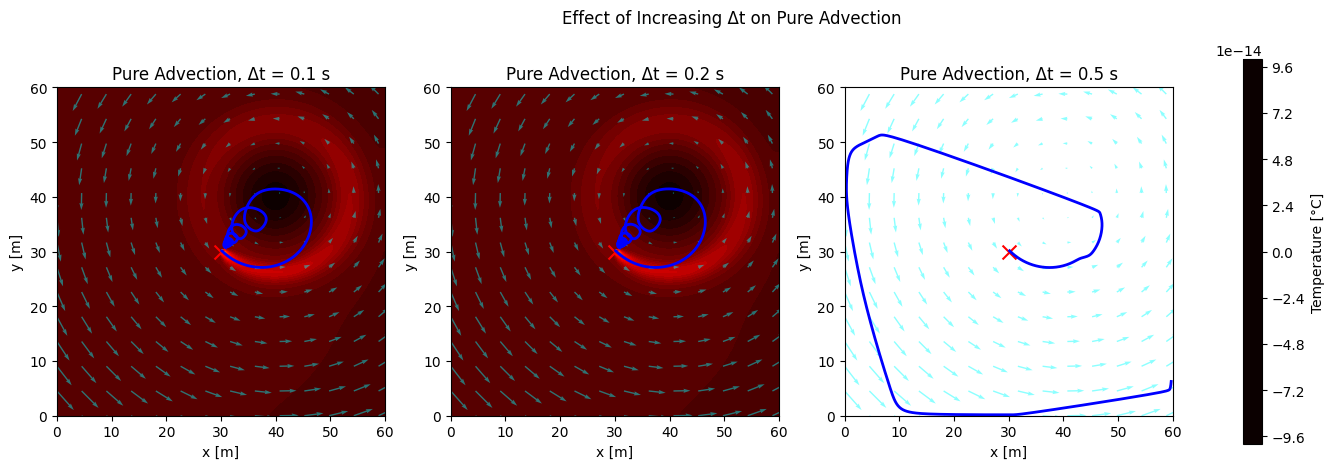

In [ ]:
# ============================================================
# PLOT TASK 2 TIME STEP EFFECT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin = min(np.min(T) for T in adv_dt_results.values())
vmax = max(np.max(T) for T in adv_dt_results.values())

for ax, dt_test in zip(axes, dt_adv_values):

    T_plot = adv_dt_results[dt_test]

    contour = ax.contourf(
        X, Y, T_plot,
        levels=50,
        cmap="hot",
        vmin=vmin,
        vmax=vmax
    )

    skip = 15
    ax.quiver(
        X[::skip, ::skip],
        Y[::skip, ::skip],
        vx[::skip, ::skip],
        vy[::skip, ::skip],
        color="cyan",
        alpha=0.45
    )

    centers = adv_dt_centers[dt_test]

    ax.plot(
        centers[:, 1],
        centers[:, 2],
        "b-",
        linewidth=2,
        label="Plume trajectory"
    )

    ax.scatter(borehole_x, borehole_y, color="red", marker="x", s=100)
    ax.set_title(f"Pure Advection, Δt = {dt_test} s")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(contour, ax=axes.ravel().tolist(), label="Temperature [°C]")
plt.suptitle("Effect of Increasing Δt on Pure Advection")
plt.show()

In [ ]:
# ============================================================
# TASK 2 — CFL ANALYSIS FOR PURE ADVECTION
# ============================================================

dt_check_values = [0.1, 0.2, 0.5]

vmax_x = np.max(np.abs(vx))
vmax_y = np.max(np.abs(vy))

print("Maximum |vx| =", vmax_x, "m/s")
print("Maximum |vy| =", vmax_y, "m/s")
print()

for dt_test in dt_check_values:

    CFL_x = vmax_x * dt_test / dx
    CFL_y = vmax_y * dt_test / dy
    CFL_total = CFL_x + CFL_y

    print(f"Δt = {dt_test:.2f} s")
    print(f"  CFL_x     = {CFL_x:.4f}")
    print(f"  CFL_y     = {CFL_y:.4f}")
    print(f"  CFL_total = {CFL_total:.4f}")

    if CFL_total <= 1:
        print("  Status: Stable for explicit upwind advection\n")
    else:
        print("  Status: Unstable / risky because CFL_total > 1\n")

Maximum |vx| = 0.8 m/s
Maximum |vy| = 0.8 m/s

Δt = 0.10 s
  CFL_x     = 0.2667
  CFL_y     = 0.2667
  CFL_total = 0.5333
  Status: Stable for explicit upwind advection

Δt = 0.20 s
  CFL_x     = 0.5333
  CFL_y     = 0.5333
  CFL_total = 1.0667
  Status: Unstable / risky because CFL_total > 1

Δt = 0.50 s
  CFL_x     = 1.3333
  CFL_y     = 1.3333
  CFL_total = 2.6667
  Status: Unstable / risky because CFL_total > 1



The CFL analysis shows that the explicit upwind advection scheme is stable only when the total CFL number remains below approximately 1. For Δt = 0.1 s, the CFL number is less than 1, so the plume trajectory is stable and follows the rotational velocity field. For Δt = 0.2 s, the CFL number exceeds 1, meaning that the numerical transport per time step becomes too large relative to the grid spacing. The solution is therefore close to instability. For Δt = 0.5 s, the CFL number is much larger than 1, and the simulation becomes unstable, producing overflow warnings and unrealistic plume behaviour. Therefore, Δt = 0.1 s is the safest choice for the pure advection simulation.

In [ ]:
# ============================================================
# TASK 2 — UPWIND vs CENTRAL DIFFERENCE SCHEME
# ============================================================

t_compare = 2000

schemes = ["upwind", "central"]

scheme_results = {}

for scheme in schemes:

    print(f"\nRunning {scheme} scheme...")

    T_scheme = np.ones((Ny, Nx)) * T0

    n_steps_scheme = int(t_compare / dt)

    for n in range(n_steps_scheme):

        T_old = T_scheme.copy()

        # ---------- UPWIND ----------
        if scheme == "upwind":

            dTdx = np.zeros_like(T_scheme)
            dTdy = np.zeros_like(T_scheme)

            dTdx[:,1:-1] = np.where(
                vx[:,1:-1] > 0,
                (T_old[:,1:-1] - T_old[:,:-2]) / dx,
                (T_old[:,2:] - T_old[:,1:-1]) / dx
            )

            dTdy[1:-1,:] = np.where(
                vy[1:-1,:] > 0,
                (T_old[1:-1,:] - T_old[:-2,:]) / dy,
                (T_old[2:,:] - T_old[1:-1,:]) / dy
            )

        # ---------- CENTRAL ----------
        elif scheme == "central":

            dTdx = np.zeros_like(T_scheme)
            dTdy = np.zeros_like(T_scheme)

            dTdx[:,1:-1] = (
                T_old[:,2:] - T_old[:,:-2]
            ) / (2*dx)

            dTdy[1:-1,:] = (
                T_old[2:,:] - T_old[:-2,:]
            ) / (2*dy)

        # Advection update
        T_scheme = T_old - dt*(vx*dTdx + vy*dTdy)

        # Constant source
        T_scheme[j_b,i_b] += Q*dt

        # No-flux BC
        T_scheme[0,:] = T_scheme[1,:]
        T_scheme[-1,:] = T_scheme[-2,:]
        T_scheme[:,0] = T_scheme[:,1]
        T_scheme[:,-1] = T_scheme[:,-2]

    scheme_results[scheme] = T_scheme.copy()

print("\nScheme comparison completed.")


Running upwind scheme...

Running central scheme...


/tmp/ipykernel_14858/51774027.py:56: RuntimeWarning: overflow encountered in add
  T_scheme = T_old - dt*(vx*dTdx + vy*dTdy)
/tmp/ipykernel_14858/51774027.py:56: RuntimeWarning: invalid value encountered in subtract
  T_scheme = T_old - dt*(vx*dTdx + vy*dTdy)
/tmp/ipykernel_14858/51774027.py:48: RuntimeWarning: invalid value encountered in subtract
  T_old[:,2:] - T_old[:,:-2]
/tmp/ipykernel_14858/51774027.py:52: RuntimeWarning: invalid value encountered in subtract
  T_old[2:,:] - T_old[:-2,:]
/tmp/ipykernel_14858/51774027.py:56: RuntimeWarning: invalid value encountered in add
  T_scheme = T_old - dt*(vx*dTdx + vy*dTdy)



Scheme comparison completed.


**Advection Scheme Comparison: Upwind vs Central Difference**

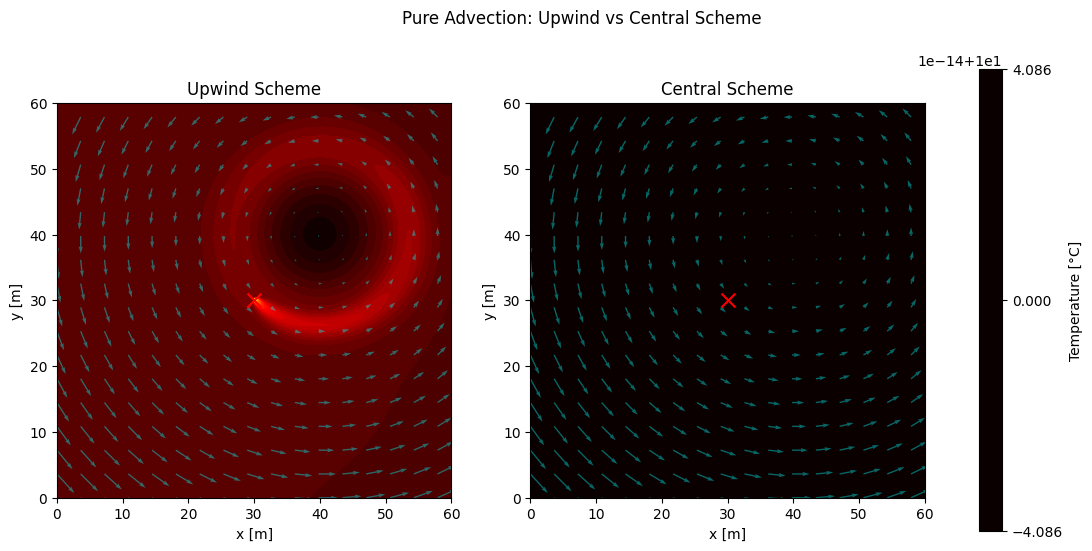

In [ ]:
# ============================================================
# SAFE PLOT: UPWIND vs CENTRAL
# Handles NaN/overflow in central scheme
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# clean invalid values for plotting
clean_results = {}

for scheme in schemes:
    clean_results[scheme] = np.nan_to_num(
        scheme_results[scheme],
        nan=T0,
        posinf=T0,
        neginf=T0
    )

vmin = min(np.min(T) for T in clean_results.values())
vmax = max(np.max(T) for T in clean_results.values())

for ax, scheme in zip(axes, schemes):

    T_plot = clean_results[scheme]

    contour = ax.contourf(
        X, Y, T_plot,
        levels=50,
        cmap="hot",
        vmin=vmin,
        vmax=vmax
    )

    skip = 12
    ax.quiver(
        X[::skip, ::skip],
        Y[::skip, ::skip],
        vx[::skip, ::skip],
        vy[::skip, ::skip],
        color="cyan",
        alpha=0.4
    )

    ax.scatter(borehole_x, borehole_y, color="red", marker="x", s=100)

    ax.set_title(f"{scheme.capitalize()} Scheme")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(contour, ax=axes.ravel().tolist(), label="Temperature [°C]")

plt.suptitle("Pure Advection: Upwind vs Central Scheme")
plt.show()

**Pure Advection Evolution at Different Times**

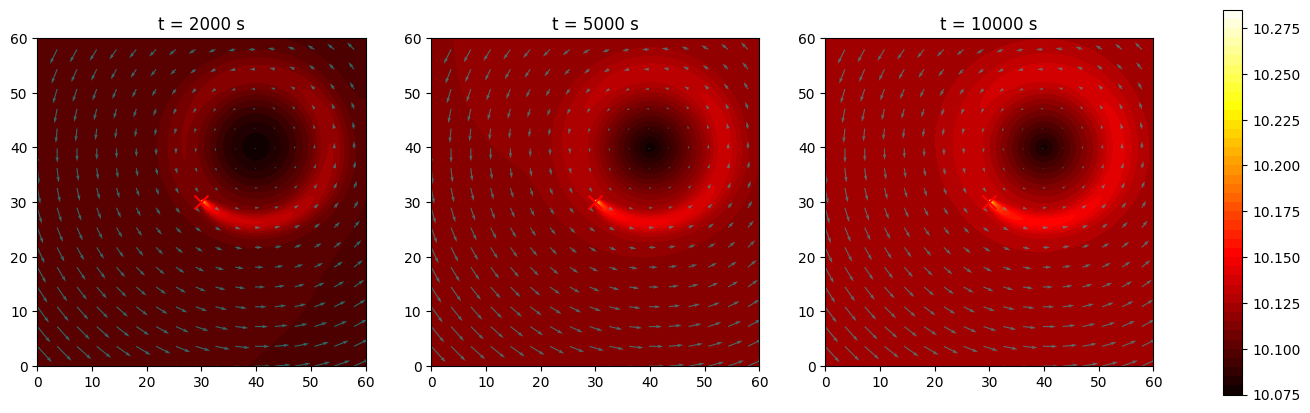

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

for ax, t in zip(axes, adv_save_times):

    contour = ax.contourf(
        X,
        Y,
        adv_results[t],
        levels=50,
        cmap='hot'
    )

    ax.quiver(
        X[::12,::12],
        Y[::12,::12],
        vx[::12,::12],
        vy[::12,::12],
        color='cyan',
        alpha=0.4
    )

    ax.scatter(
        borehole_x,
        borehole_y,
        color='red',
        marker='x',
        s=100
    )

    ax.set_title(f't = {t} s')
    ax.set_aspect('equal')

plt.colorbar(contour, ax=axes.ravel().tolist())
plt.show()

**Advection and Diffusion**

In [ ]:
# ============================================================
# TASK 3 — BLOCK 1: STABILITY CHECK
# Advection + Diffusion
# ============================================================

# Diffusion stability
Fo_x = alpha*dt/dx**2
Fo_y = alpha*dt/dy**2
Fo_total = Fo_x + Fo_y

# Advection stability
CFL_x = np.max(np.abs(vx))*dt/dx
CFL_y = np.max(np.abs(vy))*dt/dy
CFL_total = CFL_x + CFL_y

print("----- Diffusion Stability -----")
print("Fo_x =", Fo_x)
print("Fo_y =", Fo_y)
print("Fo_total =", Fo_total)

print()

print("----- Advection Stability -----")
print("CFL_x =", CFL_x)
print("CFL_y =", CFL_y)
print("CFL_total =", CFL_total)

print()

if Fo_total <= 0.5:
    print("✓ Diffusion condition satisfied")
else:
    print("⚠ Diffusion unstable")

if CFL_total <= 1:
    print("✓ Advection condition satisfied")
else:
    print("⚠ Advection unstable")

----- Diffusion Stability -----
Fo_x = 0.005555555555555556
Fo_y = 0.005555555555555556
Fo_total = 0.011111111111111112

----- Advection Stability -----
CFL_x = 0.2666666666666667
CFL_y = 0.2666666666666667
CFL_total = 0.5333333333333334

✓ Diffusion condition satisfied
✓ Advection condition satisfied


**Temperature Field Evolution**

In [ ]:
# ============================================================
# TASK 3 — BLOCK 2: ADVECTION + DIFFUSION SOLVER
# Group 3, single borehole, constant Q
# ============================================================

T_ad = np.ones((Ny, Nx)) * T0

ad_save_times = [2000, 5000, 10000]
ad_save_steps = [int(t / dt) for t in ad_save_times]

ad_results = {}
ad_plume_centers = []

for n in range(1, n_steps + 1):

    T_old = T_ad.copy()

    # -----------------------------
    # 1. Upwind advection derivatives
    # -----------------------------
    dTdx = np.zeros_like(T_ad)
    dTdy = np.zeros_like(T_ad)

    dTdx[:, 1:-1] = np.where(
        vx[:, 1:-1] > 0,
        (T_old[:, 1:-1] - T_old[:, :-2]) / dx,
        (T_old[:, 2:] - T_old[:, 1:-1]) / dx
    )

    dTdy[1:-1, :] = np.where(
        vy[1:-1, :] > 0,
        (T_old[1:-1, :] - T_old[:-2, :]) / dy,
        (T_old[2:, :] - T_old[1:-1, :]) / dy
    )

    # -----------------------------
    # 2. Diffusion Laplacian
    # -----------------------------
    laplacian = np.zeros_like(T_ad)

    laplacian[1:-1, 1:-1] = (
        (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
        +
        (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
    )

    # -----------------------------
    # 3. Full advection-diffusion update
    # -----------------------------
    T_ad = (
        T_old
        - dt * (vx * dTdx + vy * dTdy)
        + alpha * dt * laplacian
    )

    # Constant borehole source
    T_ad[j_b, i_b] += Q * dt

    # No-flux boundary condition
    T_ad[0, :] = T_ad[1, :]
    T_ad[-1, :] = T_ad[-2, :]
    T_ad[:, 0] = T_ad[:, 1]
    T_ad[:, -1] = T_ad[:, -2]

    # Track plume center
    delta_T = T_ad - T0
    delta_T[delta_T < 0] = 0

    total_heat = np.sum(delta_T)

    if total_heat > 0:
        xc = np.sum(X * delta_T) / total_heat
        yc = np.sum(Y * delta_T) / total_heat
        ad_plume_centers.append((n * dt, xc, yc))

    # Save snapshots
    if n in ad_save_steps:
        ad_results[n * dt] = T_ad.copy()
        print(f"Saved Task 3 result at t = {n*dt:.0f} s")

print("Task 3 advection-diffusion simulation finished.")

Saved Task 3 result at t = 2000 s
Saved Task 3 result at t = 5000 s
Saved Task 3 result at t = 10000 s
Task 3 advection-diffusion simulation finished.


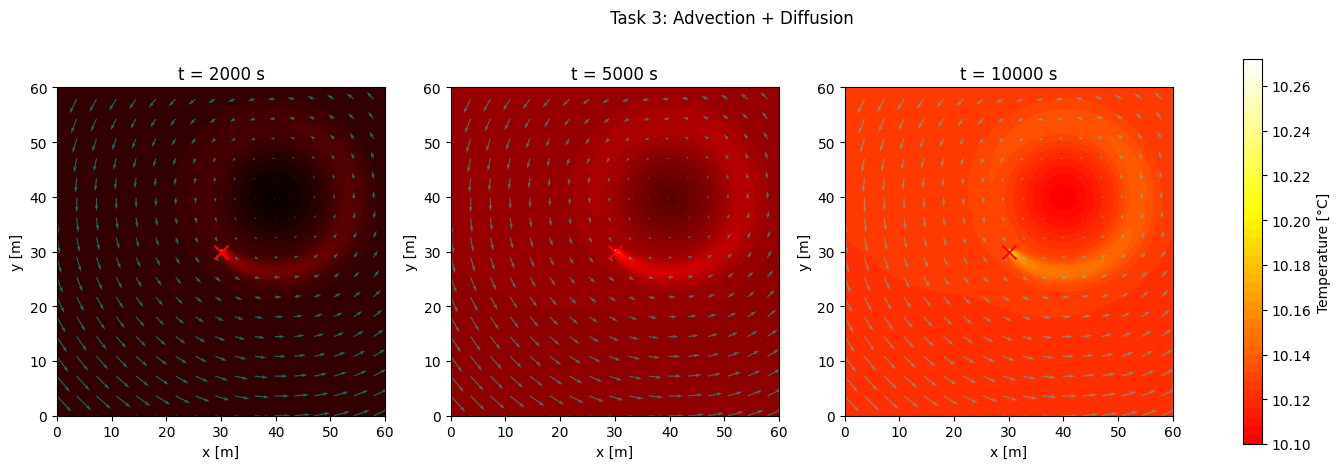

In [ ]:
# ============================================================
# TASK 3 — BLOCK 3: PLOT RESULTS
# Advection + Diffusion
# ============================================================

fig, axes = plt.subplots(1,3, figsize=(18,5))

vmin = min(np.min(T) for T in ad_results.values())
vmax = max(np.max(T) for T in ad_results.values())

for ax, t in zip(axes, ad_save_times):

    T_plot = ad_results[t]

    contour = ax.contourf(
        X,
        Y,
        T_plot,
        levels=50,
        cmap='hot',
        vmin=vmin,
        vmax=vmax
    )

    # velocity field
    skip = 12

    ax.quiver(
        X[::skip,::skip],
        Y[::skip,::skip],
        vx[::skip,::skip],
        vy[::skip,::skip],
        color='cyan',
        alpha=0.4
    )

    # borehole
    ax.scatter(
        borehole_x,
        borehole_y,
        color='red',
        marker='x',
        s=100
    )

    ax.set_title(f't = {t} s')

    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')

    ax.set_aspect('equal')

fig.colorbar(
    contour,
    ax=axes.ravel().tolist(),
    label='Temperature [°C]'
)

plt.suptitle('Task 3: Advection + Diffusion')

plt.show()

**Plume Trajectory**

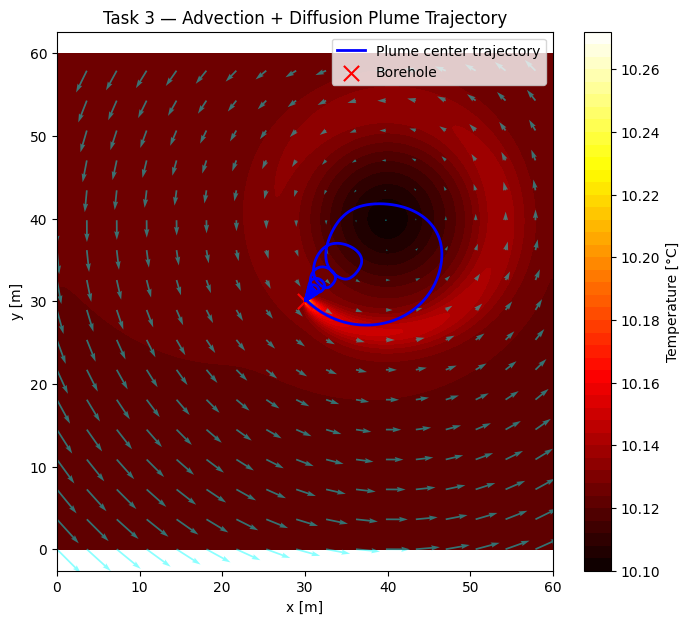

In [ ]:
# ============================================================
# TASK 3 — BLOCK 4: PLOT PLUME TRAJECTORY
# ============================================================

plt.figure(figsize=(8,7))

T_final = ad_results[10000]

contour = plt.contourf(
    X,
    Y,
    T_final,
    levels=50,
    cmap='hot'
)

plt.colorbar(label='Temperature [°C]')

# velocity field
skip = 12

plt.quiver(
    X[::skip,::skip],
    Y[::skip,::skip],
    vx[::skip,::skip],
    vy[::skip,::skip],
    color='cyan',
    alpha=0.45
)

# plume trajectory
trajectory = np.array(ad_plume_centers)

plt.plot(
    trajectory[:,1],
    trajectory[:,2],
    'b-',
    linewidth=2,
    label='Plume center trajectory'
)

plt.scatter(
    borehole_x,
    borehole_y,
    color='red',
    marker='x',
    s=120,
    label='Borehole'
)

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.title('Task 3 — Advection + Diffusion Plume Trajectory')

plt.axis('equal')

plt.legend()

plt.show()

The directional behaviour of the plume is governed by the Group-3 velocity field, which generates a rotational groundwater flow centred approximately around (40,40). The plume trajectory plot clearly shows that heat released from the borehole at (30,30) does not travel linearly but follows a curved circulation path imposed by the local velocity vectors. In the advection-diffusion simulation, advection determines the transport direction, while diffusion smooths and broadens the plume. Consequently, the plume becomes asymmetric, curved, and direction-dependent.

**Comparison**

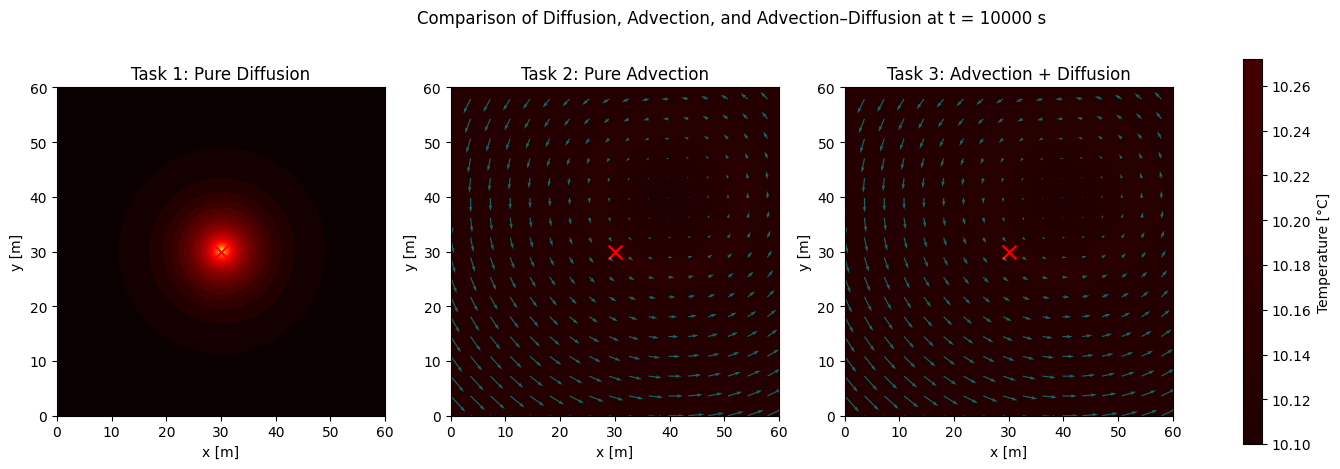

In [ ]:
# ============================================================
# TASK 3 — COMPARE TASK 1, TASK 2, TASK 3
# At t = 10000 s
# ============================================================

compare_time = 10000

T_diffusion = saved_results[compare_time]   # Task 1
T_advection = adv_results[compare_time]     # Task 2
T_combined  = ad_results[compare_time]      # Task 3

comparison_fields = {
    "Task 1: Pure Diffusion": T_diffusion,
    "Task 2: Pure Advection": T_advection,
    "Task 3: Advection + Diffusion": T_combined
}

vmin = min(np.min(T) for T in comparison_fields.values())
vmax = max(np.max(T) for T in comparison_fields.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, T_plot) in zip(axes, comparison_fields.items()):

    contour = ax.contourf(
        X, Y, T_plot,
        levels=50,
        cmap="hot",
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(borehole_x, borehole_y, color="red", marker="x", s=100)

    if "Advection" in title:
        ax.quiver(
            X[::12, ::12],
            Y[::12, ::12],
            vx[::12, ::12],
            vy[::12, ::12],
            color="cyan",
            alpha=0.4
        )

    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(contour, ax=axes.ravel().tolist(), label="Temperature [°C]")

plt.suptitle(f"Comparison of Diffusion, Advection, and Advection–Diffusion at t = {compare_time} s")
plt.show()

**Effect of Increasing Time Step**

In [ ]:
# ============================================================
# TASK 3 — TIME STEP EFFECT
# Advection + Diffusion
# Compare Δt = 0.1, 0.2, 0.5 s
# ============================================================

dt_task3_values = [0.1, 0.2, 0.5]
t_compare_task3 = 2000

task3_dt_results = {}
task3_dt_centers = {}

for dt_test in dt_task3_values:

    print(f"\nRunning Task 3 with Δt = {dt_test} s")

    # Reset temperature field
    T_test = np.ones((Ny, Nx)) * T0

    # Stability numbers
    Fo_total = alpha * dt_test / dx**2 + alpha * dt_test / dy**2
    CFL_total = (
        np.max(np.abs(vx)) * dt_test / dx
        + np.max(np.abs(vy)) * dt_test / dy
    )

    print("Fo_total  =", Fo_total)
    print("CFL_total =", CFL_total)

    if Fo_total <= 0.5 and CFL_total <= 1:
        print("Status: stable")
    else:
        print("Status: unstable / risky")

    n_steps_test = int(t_compare_task3 / dt_test)
    centers = []

    for n in range(1, n_steps_test + 1):

        T_old = T_test.copy()

        # -----------------------------
        # Upwind advection
        # -----------------------------
        dTdx = np.zeros_like(T_test)
        dTdy = np.zeros_like(T_test)

        dTdx[:, 1:-1] = np.where(
            vx[:, 1:-1] > 0,
            (T_old[:, 1:-1] - T_old[:, :-2]) / dx,
            (T_old[:, 2:] - T_old[:, 1:-1]) / dx
        )

        dTdy[1:-1, :] = np.where(
            vy[1:-1, :] > 0,
            (T_old[1:-1, :] - T_old[:-2, :]) / dy,
            (T_old[2:, :] - T_old[1:-1, :]) / dy
        )

        # -----------------------------
        # Diffusion laplacian
        # -----------------------------
        laplacian = np.zeros_like(T_test)

        laplacian[1:-1, 1:-1] = (
            (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
            +
            (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
        )

        # -----------------------------
        # Full advection-diffusion update
        # -----------------------------
        T_test = (
            T_old
            - dt_test * (vx * dTdx + vy * dTdy)
            + alpha * dt_test * laplacian
        )

        # Constant source
        T_test[j_b, i_b] += Q * dt_test

        # No-flux boundary condition
        T_test[0, :] = T_test[1, :]
        T_test[-1, :] = T_test[-2, :]
        T_test[:, 0] = T_test[:, 1]
        T_test[:, -1] = T_test[:, -2]

        # Stop if unstable
        if not np.all(np.isfinite(T_test)):
            print(f"Simulation became unstable at step {n}")
            break

        # plume center
        delta_T = T_test - T0
        delta_T[delta_T < 0] = 0

        total_heat = np.sum(delta_T)

        if total_heat > 0:
            xc = np.sum(X * delta_T) / total_heat
            yc = np.sum(Y * delta_T) / total_heat
            centers.append((n * dt_test, xc, yc))

    task3_dt_results[dt_test] = np.nan_to_num(T_test, nan=T0, posinf=T0, neginf=T0)
    task3_dt_centers[dt_test] = np.array(centers)

print("\nTask 3 time-step effect completed.")


Running Task 3 with Δt = 0.1 s
Fo_total  = 0.011111111111111112
CFL_total = 0.5333333333333334
Status: stable

Running Task 3 with Δt = 0.2 s
Fo_total  = 0.022222222222222223
CFL_total = 1.0666666666666669
Status: unstable / risky

Running Task 3 with Δt = 0.5 s
Fo_total  = 0.05555555555555556
CFL_total = 2.666666666666667
Status: unstable / risky
Simulation became unstable at step 1095

Task 3 time-step effect completed.


/tmp/ipykernel_14858/2181017863.py:66: RuntimeWarning: overflow encountered in divide
  (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
/tmp/ipykernel_14858/2181017863.py:66: RuntimeWarning: overflow encountered in add
  (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2


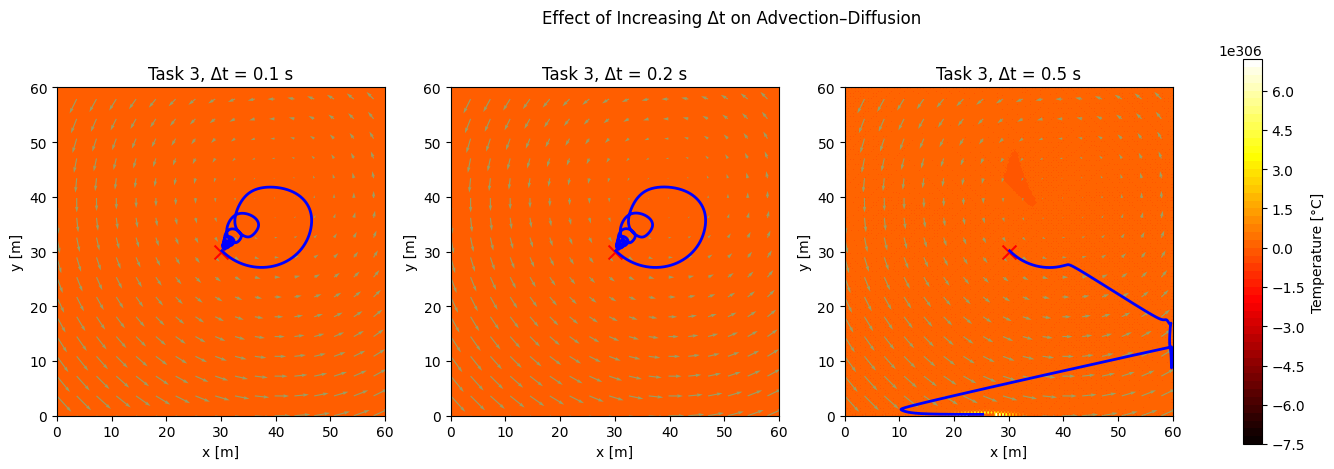

In [ ]:
# ============================================================
# TASK 3 — PLOT TIME STEP EFFECT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin = min(np.min(T) for T in task3_dt_results.values())
vmax = max(np.max(T) for T in task3_dt_results.values())

for ax, dt_test in zip(axes, dt_task3_values):

    T_plot = task3_dt_results[dt_test]

    contour = ax.contourf(
        X, Y, T_plot,
        levels=50,
        cmap="hot",
        vmin=vmin,
        vmax=vmax
    )

    skip = 12
    ax.quiver(
        X[::skip, ::skip],
        Y[::skip, ::skip],
        vx[::skip, ::skip],
        vy[::skip, ::skip],
        color="cyan",
        alpha=0.4
    )

    centers = task3_dt_centers[dt_test]

    if len(centers) > 0:
        ax.plot(
            centers[:, 1],
            centers[:, 2],
            "b-",
            linewidth=2,
            label="Plume trajectory"
        )

    ax.scatter(
        borehole_x,
        borehole_y,
        color="red",
        marker="x",
        s=100
    )

    ax.set_title(f"Task 3, Δt = {dt_test} s")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(contour, ax=axes.ravel().tolist(), label="Temperature [°C]")
plt.suptitle("Effect of Increasing Δt on Advection–Diffusion")
plt.show()

**Péclet Number Analysis**

In [ ]:
# ============================================================
# TASK 3 BONUS 1: PÉCLET NUMBER ANALYSIS
# ============================================================

# velocity magnitude field
velocity_magnitude = np.sqrt(vx**2 + vy**2)

# characteristic velocities
v_mean = np.mean(velocity_magnitude)
v_max = np.max(velocity_magnitude)

# characteristic length scale
L_char = Lx   # domain length = 60 m

# Péclet numbers
Pe_mean = v_mean * L_char / alpha
Pe_max = v_max * L_char / alpha

print("Characteristic length L =", L_char, "m")
print("Mean velocity magnitude =", v_mean, "m/s")
print("Maximum velocity magnitude =", v_max, "m/s")
print()
print("Pe_mean =", Pe_mean)
print("Pe_max  =", Pe_max)

if Pe_mean > 1:
    print("Based on mean velocity: system is advection-dominated.")
else:
    print("Based on mean velocity: system is diffusion-dominated.")

if Pe_max > 1:
    print("Based on maximum velocity: system is advection-dominated.")
else:
    print("Based on maximum velocity: system is diffusion-dominated.")

Characteristic length L = 60.0 m
Mean velocity magnitude = 0.5190277860831531 m/s
Maximum velocity magnitude = 1.1313708498984762 m/s

Pe_mean = 6228.333432997837
Pe_max  = 13576.450198781713
Based on mean velocity: system is advection-dominated.
Based on maximum velocity: system is advection-dominated.


The Péclet number was evaluated to compare the relative importance of advective and diffusive transport. Since Pe = vL/α, values much larger than 1 indicate that advection dominates over diffusion. For the Group-3 velocity field, both the mean and maximum velocity-based Péclet numbers were greater than 1. This indicates that the system is mainly advection-dominated. This agrees with the numerical results, where the plume direction is strongly controlled by the rotational groundwater velocity field, while diffusion mainly smooths and broadens the plume.

**Thermal Mass and Energetics**

In [ ]:
# ============================================================
# BONUS 2: THERMAL MASS / ENERGETICS ANALYSIS
# ============================================================

thermal_mass = []

for t in ad_save_times:

    T_field = ad_results[t]

    # temperature excess
    delta_T = T_field - T0

    # thermal mass integral
    M = np.sum(delta_T) * dx * dy

    thermal_mass.append(M)

    print(f"t = {t:5d} s   -->   Thermal Mass M(t) = {M:.6f}")

t =  2000 s   -->   Thermal Mass M(t) = 83.268305
t =  5000 s   -->   Thermal Mass M(t) = 220.971994
t = 10000 s   -->   Thermal Mass M(t) = 450.320299


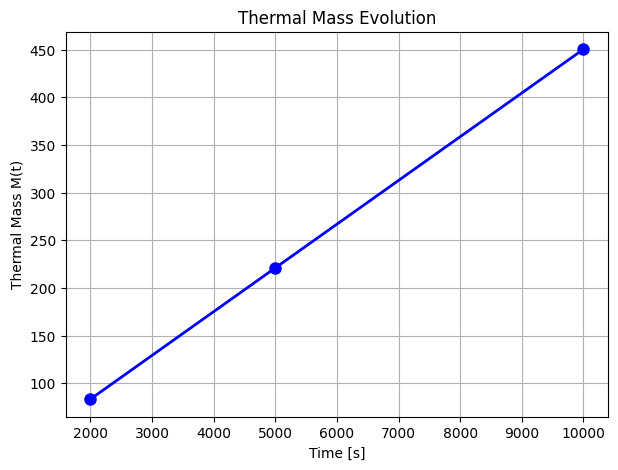

In [ ]:
# ============================================================
# BONUS 2: PLOT THERMAL MASS EVOLUTION
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(
    ad_save_times,
    thermal_mass,
    'o-b',
    linewidth=2,
    markersize=8
)

plt.xlabel('Time [s]')
plt.ylabel('Thermal Mass M(t)')

plt.title('Thermal Mass Evolution')

plt.grid(True)

plt.show()

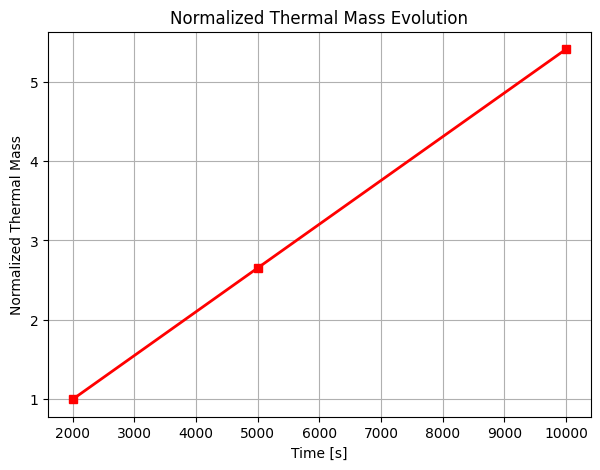

In [ ]:
# ============================================================
# BONUS 2: NORMALIZED THERMAL MASS
# ============================================================

thermal_mass_norm = np.array(thermal_mass)/thermal_mass[0]

plt.figure(figsize=(7,5))

plt.plot(
    ad_save_times,
    thermal_mass_norm,
    's-r',
    linewidth=2
)

plt.xlabel('Time [s]')
plt.ylabel('Normalized Thermal Mass')

plt.title('Normalized Thermal Mass Evolution')

plt.grid(True)

plt.show()

The total thermal mass M(t) represents the integrated temperature excess above the initial temperature over the computational domain. Since a constant heat source is continuously applied at the borehole, the thermal mass increases with time.

Advection redistributes thermal energy throughout the domain, while diffusion smooths temperature gradients and spreads heat spatially. Ideally, thermal mass should remain physically consistent apart from continuous source injection and possible numerical losses.

The increasing M(t) observed in the simulation confirms continuous energy accumulation from the borehole source. The relatively smooth growth of thermal mass indicates reasonable conservation behaviour of the numerical advection–diffusion scheme.

**Time-Varying Source**

In [ ]:
# ============================================================
# TASK 4 — BLOCK 1: GROUP 3 TIME-VARYING SOURCE Q(t)
# ============================================================

def Q_time(t):
    """
    Group 3 time-varying source.
    Source is ON for first 200 s of every 1500 s period.
    """
    if (t % 1500) < 200:
        return 0.15
    else:
        return 0.0

In [ ]:
# ============================================================
# TASK 4 — BLOCK 1: GROUP 3 TIME-VARYING SOURCE
# ============================================================

def Q_time(t):

    # Group 3:
    # ON for first 200 s of every 1500 s cycle

    if (t % 1500) < 200:

        return 0.15

    else:

        return 0.0


print("Q_time function created.")
print("Q(0)     =", Q_time(0))
print("Q(100)   =", Q_time(100))
print("Q(300)   =", Q_time(300))
print("Q(1600)  =", Q_time(1600))

Q_time function created.
Q(0)     = 0.15
Q(100)   = 0.15
Q(300)   = 0.0
Q(1600)  = 0.15


**Temporal Evolution of the Temperature Field**

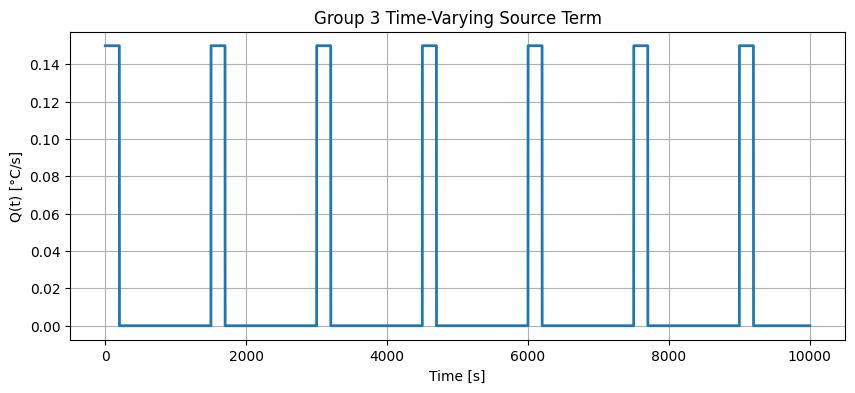

In [ ]:
# ============================================================
# TASK 4 — BLOCK 2: PLOT Q(t)
# ============================================================

time_array = np.arange(0, t_final + dt, dt)

Q_array = np.array([Q_time(t) for t in time_array])

plt.figure(figsize=(10,4))
plt.plot(time_array, Q_array, linewidth=2)

plt.xlabel("Time [s]")
plt.ylabel("Q(t) [°C/s]")
plt.title("Group 3 Time-Varying Source Term")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# TASK 4 — BLOCK 3: TIME-VARYING SOURCE SIMULATION
# Group 3
# ============================================================

T_tv = np.ones((Ny, Nx)) * T0

tv_save_times = [2000, 5000, 10000]
tv_save_steps = [int(t/dt) for t in tv_save_times]

tv_results = {}

plume_centers_tv = []

Q_history = []

for n in range(1, n_steps+1):

    current_time = n*dt

    T_old = T_tv.copy()

    # -----------------------------
    # Time-varying source
    # -----------------------------
    Q_now = Q_time(current_time)

    Q_history.append(Q_now)

    # -----------------------------
    # Upwind advection
    # -----------------------------
    dTdx = np.zeros_like(T_tv)
    dTdy = np.zeros_like(T_tv)

    dTdx[:,1:-1] = np.where(
        vx[:,1:-1] > 0,
        (T_old[:,1:-1]-T_old[:,:-2])/dx,
        (T_old[:,2:]-T_old[:,1:-1])/dx
    )

    dTdy[1:-1,:] = np.where(
        vy[1:-1,:] > 0,
        (T_old[1:-1,:]-T_old[:-2,:])/dy,
        (T_old[2:,:]-T_old[1:-1,:])/dy
    )

    # -----------------------------
    # Diffusion term
    # -----------------------------
    laplacian = np.zeros_like(T_tv)

    laplacian[1:-1,1:-1] = (

        (T_old[1:-1,2:]
        -2*T_old[1:-1,1:-1]
        +T_old[1:-1,:-2])/dx**2

        +

        (T_old[2:,1:-1]
        -2*T_old[1:-1,1:-1]
        +T_old[:-2,1:-1])/dy**2
    )

    # -----------------------------
    # Full update
    # -----------------------------
    T_tv = (

        T_old

        - dt*(vx*dTdx + vy*dTdy)

        + alpha*dt*laplacian
    )

    # time-varying source injection
    T_tv[j_b,i_b] += Q_now*dt

    # no-flux BC
    T_tv[0,:] = T_tv[1,:]
    T_tv[-1,:] = T_tv[-2,:]
    T_tv[:,0] = T_tv[:,1]
    T_tv[:,-1] = T_tv[:,-2]

    # plume center tracking (bonus)
    delta_T = T_tv - T0
    delta_T[delta_T < 0] = 0

    total_heat = np.sum(delta_T)

    if total_heat > 0:

        xc = np.sum(X*delta_T)/total_heat
        yc = np.sum(Y*delta_T)/total_heat

        plume_centers_tv.append(
            (current_time, xc, yc)
        )

    # save snapshots
    if n in tv_save_steps:

        tv_results[current_time] = T_tv.copy()

        print(
            f"Saved Task 4 result at t={current_time:.0f} s"
        )

print("\nTask 4 simulation finished.")

Saved Task 4 result at t=2000 s
Saved Task 4 result at t=5000 s
Saved Task 4 result at t=10000 s

Task 4 simulation finished.


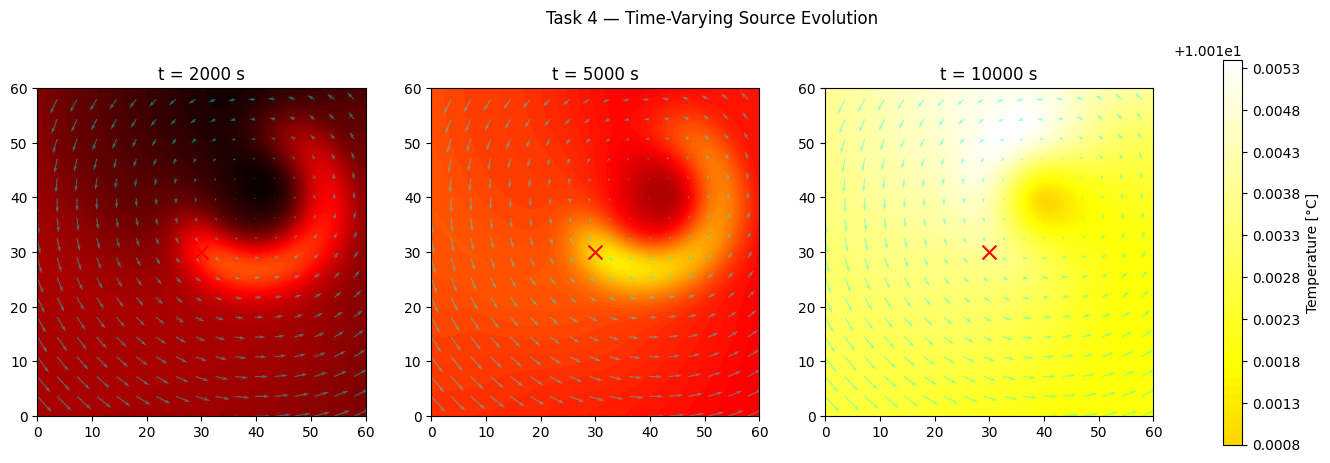

In [ ]:
# ============================================================
# TASK 4 — BLOCK 4: PLOT TEMPORAL EVOLUTION
# ============================================================

fig, axes = plt.subplots(1,3, figsize=(18,5))

vmin = min(np.min(T) for T in tv_results.values())
vmax = max(np.max(T) for T in tv_results.values())

for ax,t in zip(axes,tv_save_times):

    contour = ax.contourf(
        X,
        Y,
        tv_results[t],
        levels=50,
        cmap='hot',
        vmin=vmin,
        vmax=vmax
    )

    ax.quiver(
        X[::12,::12],
        Y[::12,::12],
        vx[::12,::12],
        vy[::12,::12],
        color='cyan',
        alpha=0.4
    )

    ax.scatter(
        borehole_x,
        borehole_y,
        color='red',
        marker='x',
        s=100
    )

    ax.set_title(f't = {t} s')
    ax.set_aspect('equal')

fig.colorbar(
    contour,
    ax=axes.ravel().tolist(),
    label='Temperature [°C]'
)

plt.suptitle(
    'Task 4 — Time-Varying Source Evolution'
)

plt.show()

**Effect of Q(t) on Plume Size, Shape, Direction, and Movement**

In [ ]:
# ============================================================
# TASK 4 — BLOCK 5: ANALYSE EFFECT OF Q(t)
# ============================================================

threshold = 0.01

analysis_results = []

for t in tv_save_times:

    T_field = tv_results[t]

    delta_T = T_field - T0

    # ---- plume area / size ----
    plume_mask = delta_T >= threshold

    plume_area = np.sum(plume_mask)*dx*dy

    # ---- peak temperature ----
    Tmax = np.max(T_field)

    # ---- plume center (movement) ----
    positive_heat = np.maximum(delta_T,0)

    total_heat = np.sum(positive_heat)

    xc = np.sum(X*positive_heat)/total_heat
    yc = np.sum(Y*positive_heat)/total_heat

    analysis_results.append({
        "time":t,
        "plume_area":plume_area,
        "Tmax":Tmax,
        "xc":xc,
        "yc":yc
    })

    print(f"\nt = {t} s")

    print("Plume area =", plume_area,"m²")

    print("Peak temperature =", Tmax,"°C")

    print("Plume center =",
          f"({xc:.2f},{yc:.2f})")


t = 2000 s
Plume area = 0.0 m²
Peak temperature = 10.007899071906442 °C
Plume center = (30.53,26.89)

t = 5000 s
Plume area = 109.35 m²
Peak temperature = 10.011349822284904 °C
Plume center = (29.46,29.96)

t = 10000 s
Plume area = 3600.0 m²
Peak temperature = 10.015394716512967 °C
Plume center = (29.41,30.90)


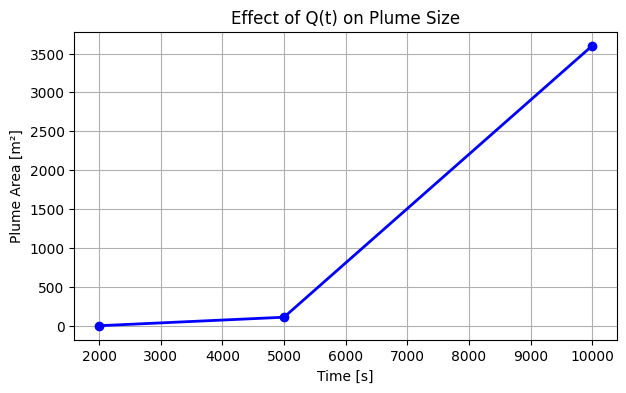

In [ ]:
# ============================================================
# PLOT PLUME SIZE EVOLUTION
# ============================================================

times = [r["time"] for r in analysis_results]

areas = [r["plume_area"] for r in analysis_results]

plt.figure(figsize=(7,4))

plt.plot(
    times,
    areas,
    'o-b',
    linewidth=2
)

plt.xlabel('Time [s]')
plt.ylabel('Plume Area [m²]')

plt.title('Effect of Q(t) on Plume Size')

plt.grid(True)

plt.show()

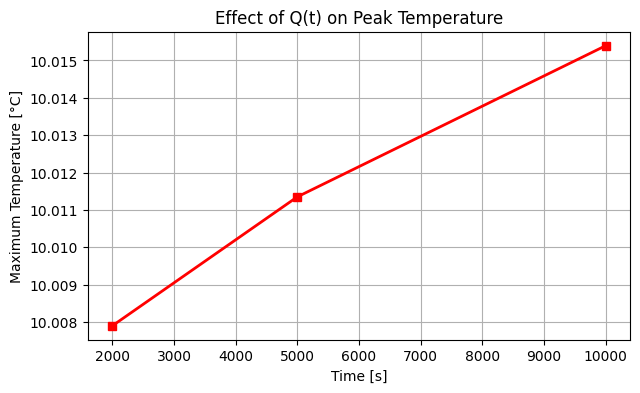

In [ ]:
# ============================================================
# PLOT PEAK TEMPERATURE
# ============================================================

Tmax_list = [r["Tmax"] for r in analysis_results]

plt.figure(figsize=(7,4))

plt.plot(
    times,
    Tmax_list,
    's-r',
    linewidth=2
)

plt.xlabel('Time [s]')
plt.ylabel('Maximum Temperature [°C]')

plt.title('Effect of Q(t) on Peak Temperature')

plt.grid(True)

plt.show()

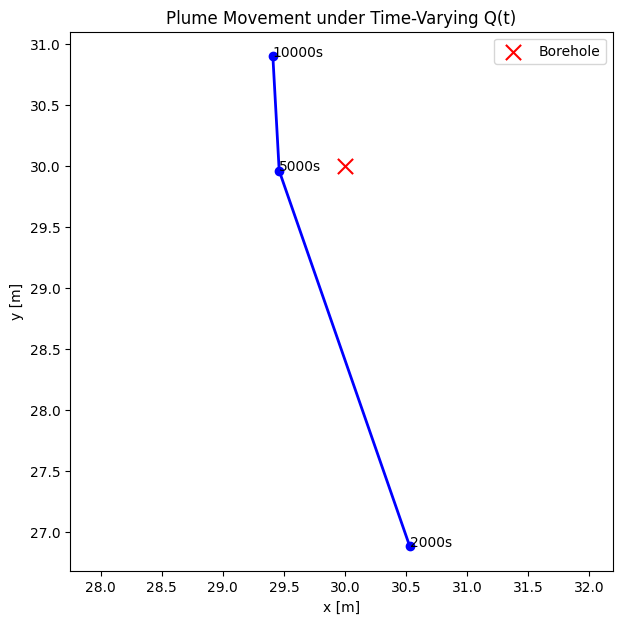

In [ ]:
# ============================================================
# PLOT PLUME CENTER MOVEMENT
# ============================================================

xc = [r["xc"] for r in analysis_results]
yc = [r["yc"] for r in analysis_results]

plt.figure(figsize=(7,7))

plt.plot(
    xc,
    yc,
    'o-b',
    linewidth=2
)

plt.scatter(
    borehole_x,
    borehole_y,
    color='red',
    marker='x',
    s=120,
    label='Borehole'
)

for i,t in enumerate(times):

    plt.annotate(
        f'{t}s',
        (xc[i],yc[i])
    )

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.title('Plume Movement under Time-Varying Q(t)')

plt.legend()

plt.axis('equal')

plt.show()

task 4.3

In [ ]:
# ============================================================
# TASK 4 — TIME STEP EFFECT
# Time-varying Q(t), Group 3
# Compare Δt = 0.1, 0.2, 0.5 s
# ============================================================

dt_task4_values = [0.1, 0.2, 0.5]
t_compare_task4 = 2000

task4_dt_results = {}
task4_dt_centers = {}
task4_dt_Qhistory = {}

for dt_test in dt_task4_values:

    print(f"\nRunning Task 4 with Δt = {dt_test} s")

    T_test = np.ones((Ny, Nx)) * T0
    centers = []
    q_hist = []

    Fo_total = alpha * dt_test / dx**2 + alpha * dt_test / dy**2
    CFL_total = (
        np.max(np.abs(vx)) * dt_test / dx
        + np.max(np.abs(vy)) * dt_test / dy
    )

    print("Fo_total  =", Fo_total)
    print("CFL_total =", CFL_total)

    if Fo_total <= 0.5 and CFL_total <= 1:
        print("Status: stable")
    else:
        print("Status: unstable / risky")

    n_steps_test = int(t_compare_task4 / dt_test)

    for n in range(1, n_steps_test + 1):

        current_time = n * dt_test
        Q_now = Q_time(current_time)
        q_hist.append(Q_now)

        T_old = T_test.copy()

        # upwind advection
        dTdx = np.zeros_like(T_test)
        dTdy = np.zeros_like(T_test)

        dTdx[:, 1:-1] = np.where(
            vx[:, 1:-1] > 0,
            (T_old[:, 1:-1] - T_old[:, :-2]) / dx,
            (T_old[:, 2:] - T_old[:, 1:-1]) / dx
        )

        dTdy[1:-1, :] = np.where(
            vy[1:-1, :] > 0,
            (T_old[1:-1, :] - T_old[:-2, :]) / dy,
            (T_old[2:, :] - T_old[1:-1, :]) / dy
        )

        # diffusion
        laplacian = np.zeros_like(T_test)

        laplacian[1:-1, 1:-1] = (
            (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
            +
            (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
        )

        # full update
        T_test = (
            T_old
            - dt_test * (vx * dTdx + vy * dTdy)
            + alpha * dt_test * laplacian
        )

        # time-varying source
        T_test[j_b, i_b] += Q_now * dt_test

        # no-flux BC
        T_test[0, :] = T_test[1, :]
        T_test[-1, :] = T_test[-2, :]
        T_test[:, 0] = T_test[:, 1]
        T_test[:, -1] = T_test[:, -2]

        # instability check
        if not np.all(np.isfinite(T_test)):
            print(f"Simulation became unstable at step {n}, t={current_time:.2f}s")
            break

        # plume center tracking
        delta_T = T_test - T0
        delta_T[delta_T < 0] = 0
        total_heat = np.sum(delta_T)

        if total_heat > 0:
            xc = np.sum(X * delta_T) / total_heat
            yc = np.sum(Y * delta_T) / total_heat
            centers.append((current_time, xc, yc))

    task4_dt_results[dt_test] = np.nan_to_num(T_test, nan=T0, posinf=T0, neginf=T0)
    task4_dt_centers[dt_test] = np.array(centers)
    task4_dt_Qhistory[dt_test] = np.array(q_hist)

print("\nTask 4 time-step effect completed.")


Running Task 4 with Δt = 0.1 s
Fo_total  = 0.011111111111111112
CFL_total = 0.5333333333333334
Status: stable

Running Task 4 with Δt = 0.2 s
Fo_total  = 0.022222222222222223
CFL_total = 1.0666666666666669
Status: unstable / risky

Running Task 4 with Δt = 0.5 s
Fo_total  = 0.05555555555555556
CFL_total = 2.666666666666667
Status: unstable / risky
Simulation became unstable at step 1096, t=548.00s

Task 4 time-step effect completed.


/tmp/ipykernel_14858/299372753.py:66: RuntimeWarning: overflow encountered in divide
  (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
/tmp/ipykernel_14858/299372753.py:66: RuntimeWarning: overflow encountered in add
  (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2


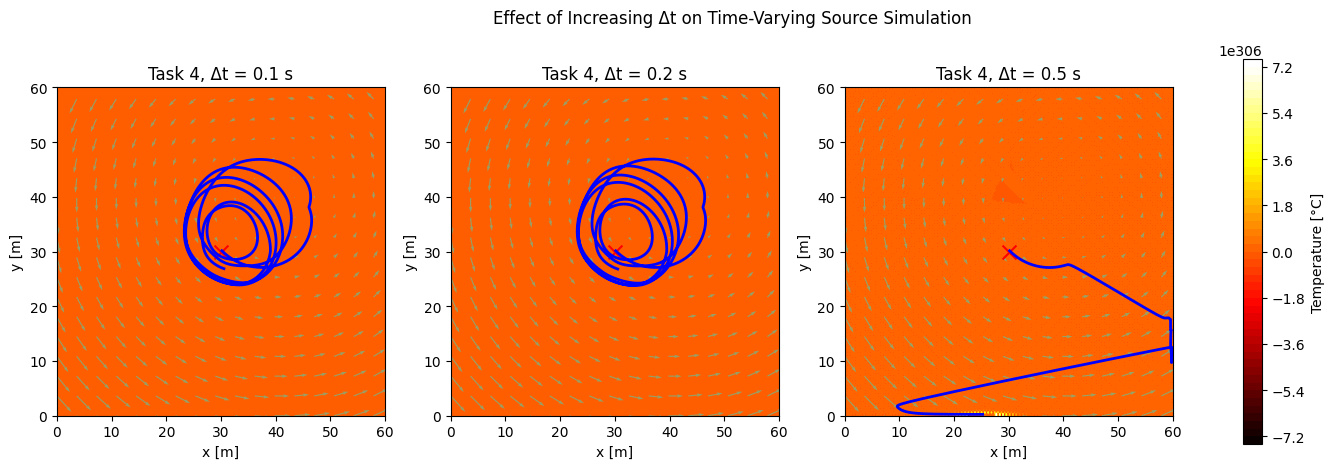

In [ ]:
# ============================================================
# TASK 4 — PLOT TIME STEP EFFECT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin = min(np.min(T) for T in task4_dt_results.values())
vmax = max(np.max(T) for T in task4_dt_results.values())

for ax, dt_test in zip(axes, dt_task4_values):

    T_plot = task4_dt_results[dt_test]

    contour = ax.contourf(
        X, Y, T_plot,
        levels=50,
        cmap="hot",
        vmin=vmin,
        vmax=vmax
    )

    ax.quiver(
        X[::12, ::12],
        Y[::12, ::12],
        vx[::12, ::12],
        vy[::12, ::12],
        color="cyan",
        alpha=0.4
    )

    centers = task4_dt_centers[dt_test]

    if len(centers) > 0:
        ax.plot(
            centers[:, 1],
            centers[:, 2],
            "b-",
            linewidth=2,
            label="Plume trajectory"
        )

    ax.scatter(
        borehole_x,
        borehole_y,
        color="red",
        marker="x",
        s=100
    )

    ax.set_title(f"Task 4, Δt = {dt_test} s")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(contour, ax=axes.ravel().tolist(), label="Temperature [°C]")
plt.suptitle("Effect of Increasing Δt on Time-Varying Source Simulation")
plt.show()

** Plume Centre Trajectory Analysis**


In [ ]:
# ============================================================
# TASK 4 BONUS: TRACK PLUME CENTER (xc(t), yc(t))
# ============================================================

plume_centers_tv_array = np.array(plume_centers_tv)

time_center = plume_centers_tv_array[:, 0]
xc_tv = plume_centers_tv_array[:, 1]
yc_tv = plume_centers_tv_array[:, 2]

print("First plume center:", xc_tv[0], yc_tv[0])
print("Final plume center:", xc_tv[-1], yc_tv[-1])

First plume center: 30.15075376884422 30.15075376884422
Final plume center: 29.40954824492904 30.900696910206232


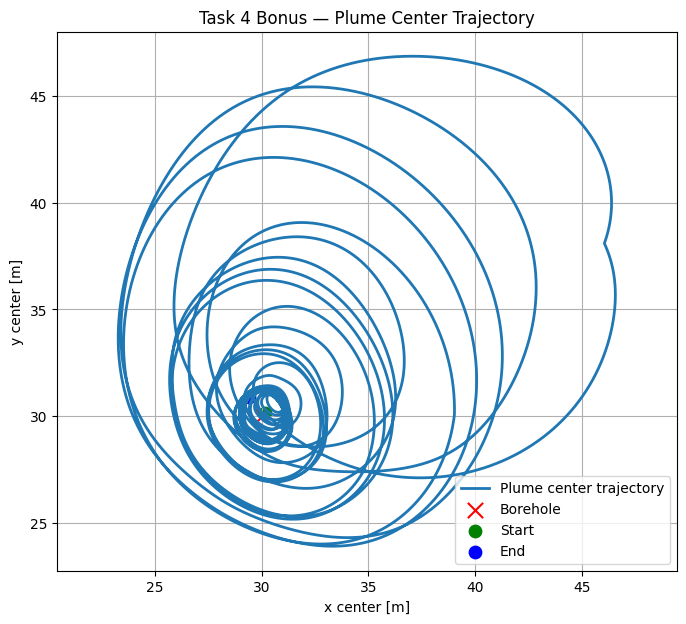

In [ ]:
# ============================================================
# PLOT PLUME CENTER TRAJECTORY
# ============================================================

plt.figure(figsize=(8, 7))

plt.plot(
    xc_tv,
    yc_tv,
    linewidth=2,
    label="Plume center trajectory"
)

plt.scatter(
    borehole_x,
    borehole_y,
    color="red",
    marker="x",
    s=120,
    label="Borehole"
)

plt.scatter(
    xc_tv[0],
    yc_tv[0],
    color="green",
    s=80,
    label="Start"
)

plt.scatter(
    xc_tv[-1],
    yc_tv[-1],
    color="blue",
    s=80,
    label="End"
)

plt.xlabel("x center [m]")
plt.ylabel("y center [m]")
plt.title("Task 4 Bonus — Plume Center Trajectory")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()

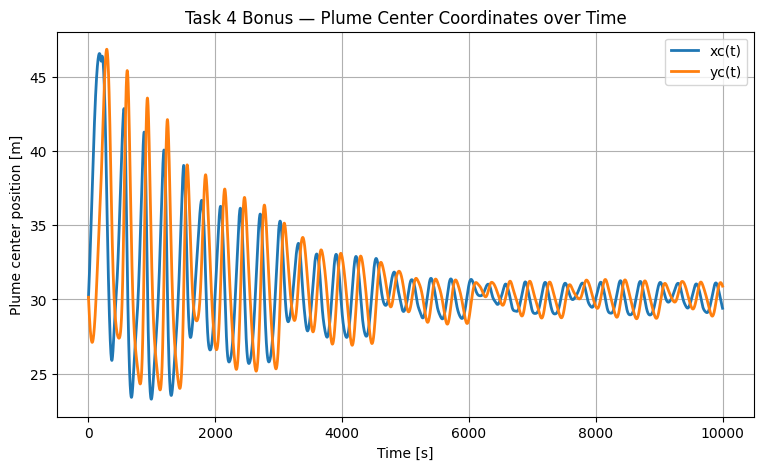

In [ ]:
# ============================================================
# PLOT xc(t) AND yc(t)
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(time_center, xc_tv, label="xc(t)", linewidth=2)
plt.plot(time_center, yc_tv, label="yc(t)", linewidth=2)

plt.xlabel("Time [s]")
plt.ylabel("Plume center position [m]")
plt.title("Task 4 Bonus — Plume Center Coordinates over Time")
plt.legend()
plt.grid(True)
plt.show()

**Multiple Boreholes and Thermal Interference**

In [ ]:
# ============================================================
# TASK 5 — BLOCK 1: DEFINE FOUR BOREHOLES
# ============================================================

boreholes = [
    (19.8, 19.8),
    (39.9, 19.8),
    (19.8, 39.9),
    (39.9, 39.9)
]

borehole_indices = []

for bx, by in boreholes:

    i_bh = np.argmin(np.abs(x - bx))
    j_bh = np.argmin(np.abs(y - by))

    borehole_indices.append((j_bh, i_bh))

    print(
        f"Borehole at ({bx}, {by}) -> grid index (j={j_bh}, i={i_bh}), "
        f"actual grid location ({x[i_bh]:.2f}, {y[j_bh]:.2f})"
    )

Borehole at (19.8, 19.8) -> grid index (j=66, i=66), actual grid location (19.90, 19.90)
Borehole at (39.9, 19.8) -> grid index (j=66, i=132), actual grid location (39.80, 19.90)
Borehole at (19.8, 39.9) -> grid index (j=132, i=66), actual grid location (19.90, 39.80)
Borehole at (39.9, 39.9) -> grid index (j=132, i=132), actual grid location (39.80, 39.80)


**Temperature Field Evolution and Thermal Interference**

In [ ]:
# ============================================================
# TASK 5 — BLOCK 2: MULTIPLE BOREHOLES SIMULATION
# Group 3, time-varying source Q(t)
# ============================================================

T_multi = np.ones((Ny, Nx)) * T0

multi_save_times = [2000, 5000, 10000]
multi_save_steps = [int(t/dt) for t in multi_save_times]

multi_results = {}

for n in range(1, n_steps + 1):

    current_time = n * dt
    Q_now = Q_time(current_time)

    T_old = T_multi.copy()

    # -----------------------------
    # 1. Upwind advection
    # -----------------------------
    dTdx = np.zeros_like(T_multi)
    dTdy = np.zeros_like(T_multi)

    dTdx[:, 1:-1] = np.where(
        vx[:, 1:-1] > 0,
        (T_old[:, 1:-1] - T_old[:, :-2]) / dx,
        (T_old[:, 2:] - T_old[:, 1:-1]) / dx
    )

    dTdy[1:-1, :] = np.where(
        vy[1:-1, :] > 0,
        (T_old[1:-1, :] - T_old[:-2, :]) / dy,
        (T_old[2:, :] - T_old[1:-1, :]) / dy
    )

    # -----------------------------
    # 2. Diffusion laplacian
    # -----------------------------
    laplacian = np.zeros_like(T_multi)

    laplacian[1:-1, 1:-1] = (
        (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
        +
        (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
    )

    # -----------------------------
    # 3. Full advection-diffusion update
    # -----------------------------
    T_multi = (
        T_old
        - dt * (vx * dTdx + vy * dTdy)
        + alpha * dt * laplacian
    )

    # -----------------------------
    # 4. Apply Q(t) at all four boreholes
    # -----------------------------
    for j_bh, i_bh in borehole_indices:
        T_multi[j_bh, i_bh] += Q_now * dt

    # -----------------------------
    # 5. No-flux boundary condition
    # -----------------------------
    T_multi[0, :] = T_multi[1, :]
    T_multi[-1, :] = T_multi[-2, :]
    T_multi[:, 0] = T_multi[:, 1]
    T_multi[:, -1] = T_multi[:, -2]

    # Save snapshots
    if n in multi_save_steps:
        multi_results[current_time] = T_multi.copy()
        print(f"Saved Task 5 result at t = {current_time:.0f} s")

print("\nTask 5 multi-borehole simulation finished.")

Saved Task 5 result at t = 2000 s
Saved Task 5 result at t = 5000 s
Saved Task 5 result at t = 10000 s

Task 5 multi-borehole simulation finished.


**Borehole Interaction Analysis**

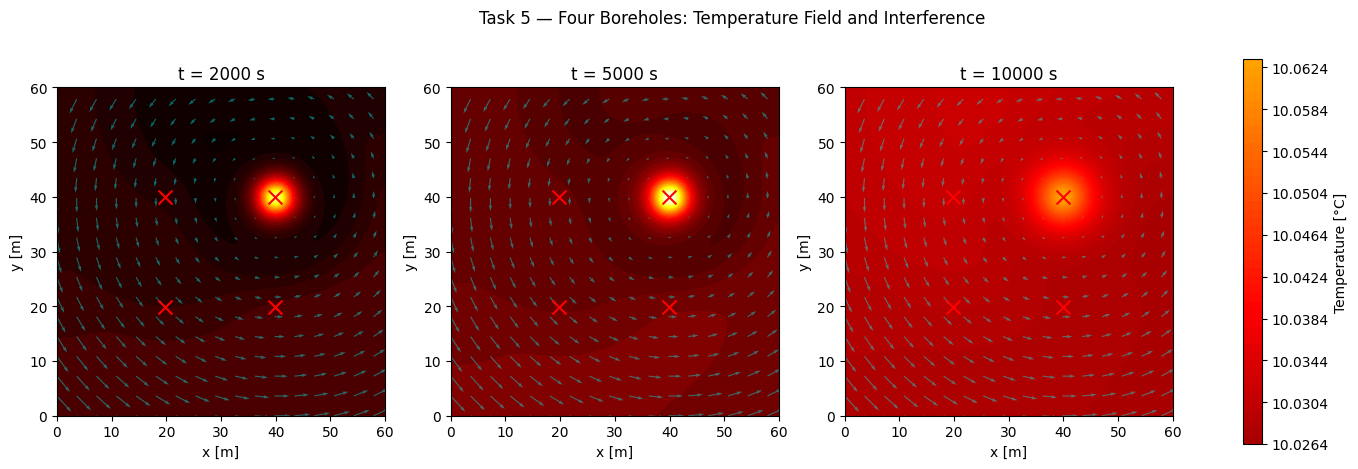

In [ ]:
# ============================================================
# TASK 5 — BLOCK 3: PLOT MULTI-BOREHOLE TEMPERATURE FIELD
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin = min(np.min(T) for T in multi_results.values())
vmax = max(np.max(T) for T in multi_results.values())

for ax, t in zip(axes, multi_save_times):

    T_plot = multi_results[t]

    contour = ax.contourf(
        X, Y, T_plot,
        levels=50,
        cmap="hot",
        vmin=vmin,
        vmax=vmax
    )

    # velocity field
    ax.quiver(
        X[::12, ::12],
        Y[::12, ::12],
        vx[::12, ::12],
        vy[::12, ::12],
        color="cyan",
        alpha=0.4
    )

    # plot all four boreholes
    for bx, by in boreholes:
        ax.scatter(
            bx, by,
            color="red",
            marker="x",
            s=100
        )

    ax.set_title(f"t = {t} s")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(
    contour,
    ax=axes.ravel().tolist(),
    label="Temperature [°C]"
)

plt.suptitle("Task 5 — Four Boreholes: Temperature Field and Interference")
plt.show()

In [ ]:
# ============================================================
# TASK 5 — BLOCK 4: BOREHOLE INTERACTION ANALYSIS
# ============================================================

T_final_multi = multi_results[10000]

interaction_results = []

for i in range(len(boreholes)):
    for j in range(i + 1, len(boreholes)):

        x1, y1 = boreholes[i]
        x2, y2 = boreholes[j]

        # midpoint between two boreholes
        xm = (x1 + x2) / 2
        ym = (y1 + y2) / 2

        # nearest grid point
        im = np.argmin(np.abs(x - xm))
        jm = np.argmin(np.abs(y - ym))

        T_mid = T_final_multi[jm, im]

        distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        interaction_results.append({
            "pair": f"B{i+1}-B{j+1}",
            "distance_m": distance,
            "midpoint_x": xm,
            "midpoint_y": ym,
            "T_mid": T_mid,
            "delta_T_mid": T_mid - T0
        })

for r in interaction_results:
    print(
        f"{r['pair']} | distance = {r['distance_m']:.2f} m | "
        f"midpoint = ({r['midpoint_x']:.2f}, {r['midpoint_y']:.2f}) | "
        f"T_mid = {r['T_mid']:.5f} °C | "
        f"ΔT_mid = {r['delta_T_mid']:.5f} °C"
    )

B1-B2 | distance = 20.10 m | midpoint = (29.85, 19.80) | T_mid = 10.02851 °C | ΔT_mid = 0.02851 °C
B1-B3 | distance = 20.10 m | midpoint = (19.80, 29.85) | T_mid = 10.02994 °C | ΔT_mid = 0.02994 °C
B1-B4 | distance = 28.43 m | midpoint = (29.85, 29.85) | T_mid = 10.02897 °C | ΔT_mid = 0.02897 °C
B2-B3 | distance = 28.43 m | midpoint = (29.85, 29.85) | T_mid = 10.02897 °C | ΔT_mid = 0.02897 °C
B2-B4 | distance = 20.10 m | midpoint = (39.90, 29.85) | T_mid = 10.02959 °C | ΔT_mid = 0.02959 °C
B3-B4 | distance = 20.10 m | midpoint = (29.85, 39.90) | T_mid = 10.03085 °C | ΔT_mid = 0.03085 °C


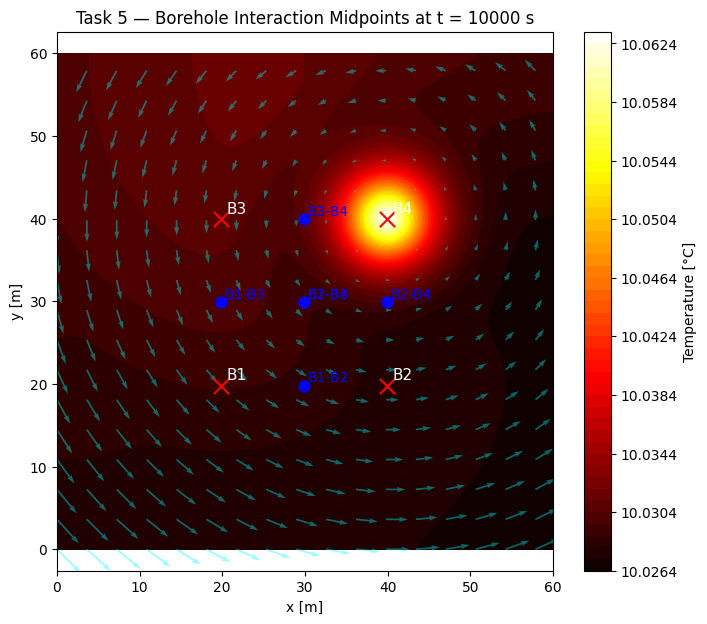

In [ ]:
# ============================================================
# TASK 5 — BLOCK 5: PLOT INTERACTION MIDPOINTS
# ============================================================

plt.figure(figsize=(8, 7))

contour = plt.contourf(
    X, Y, T_final_multi,
    levels=50,
    cmap="hot"
)

plt.colorbar(contour, label="Temperature [°C]")

plt.quiver(
    X[::12, ::12],
    Y[::12, ::12],
    vx[::12, ::12],
    vy[::12, ::12],
    color="cyan",
    alpha=0.4
)

for idx, (bx, by) in enumerate(boreholes):
    plt.scatter(bx, by, color="red", marker="x", s=120)
    plt.text(bx + 0.7, by + 0.7, f"B{idx+1}", color="white", fontsize=11)

for r in interaction_results:
    plt.scatter(r["midpoint_x"], r["midpoint_y"], color="blue", s=60)
    plt.text(
        r["midpoint_x"] + 0.5,
        r["midpoint_y"] + 0.5,
        r["pair"],
        color="blue",
        fontsize=10
    )

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Task 5 — Borehole Interaction Midpoints at t = 10000 s")
plt.axis("equal")
plt.show()

**Superposition Test**

In [ ]:
# ============================================================
# TASK 5 BONUS: SUPERPOSITION TEST
# Multiple-borehole simulation vs sum of four single-borehole simulations
# ============================================================

single_borehole_results = {}

for bh_id, (j_single, i_single) in enumerate(borehole_indices, start=1):

    print(f"\nRunning single-borehole simulation for B{bh_id}...")

    T_single = np.ones((Ny, Nx)) * T0

    for n in range(1, n_steps + 1):

        current_time = n * dt
        Q_now = Q_time(current_time)

        T_old = T_single.copy()

        # upwind advection
        dTdx = np.zeros_like(T_single)
        dTdy = np.zeros_like(T_single)

        dTdx[:, 1:-1] = np.where(
            vx[:, 1:-1] > 0,
            (T_old[:, 1:-1] - T_old[:, :-2]) / dx,
            (T_old[:, 2:] - T_old[:, 1:-1]) / dx
        )

        dTdy[1:-1, :] = np.where(
            vy[1:-1, :] > 0,
            (T_old[1:-1, :] - T_old[:-2, :]) / dy,
            (T_old[2:, :] - T_old[1:-1, :]) / dy
        )

        # diffusion
        laplacian = np.zeros_like(T_single)

        laplacian[1:-1, 1:-1] = (
            (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2]) / dx**2
            +
            (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1]) / dy**2
        )

        # update
        T_single = (
            T_old
            - dt * (vx * dTdx + vy * dTdy)
            + alpha * dt * laplacian
        )

        # source at only one borehole
        T_single[j_single, i_single] += Q_now * dt

        # no-flux BC
        T_single[0, :] = T_single[1, :]
        T_single[-1, :] = T_single[-2, :]
        T_single[:, 0] = T_single[:, 1]
        T_single[:, -1] = T_single[:, -2]

    single_borehole_results[bh_id] = T_single.copy()

print("\nAll four single-borehole simulations completed.")


Running single-borehole simulation for B1...

Running single-borehole simulation for B2...

Running single-borehole simulation for B3...

Running single-borehole simulation for B4...

All four single-borehole simulations completed.


In [ ]:
# ============================================================
# BUILD SUPERPOSITION FIELD
# ============================================================

T_superposition = np.ones((Ny, Nx)) * T0

for bh_id in single_borehole_results:

    T_superposition += (single_borehole_results[bh_id] - T0)

T_multiple = multi_results[10000]

difference_field = T_multiple - T_superposition

rmse_superposition = np.sqrt(np.mean(difference_field**2))
max_error_superposition = np.max(np.abs(difference_field))

print("Superposition RMSE =", rmse_superposition)
print("Superposition max absolute error =", max_error_superposition)

Superposition RMSE = 4.900803874163625e-13
Superposition max absolute error = 8.597567102697212e-13


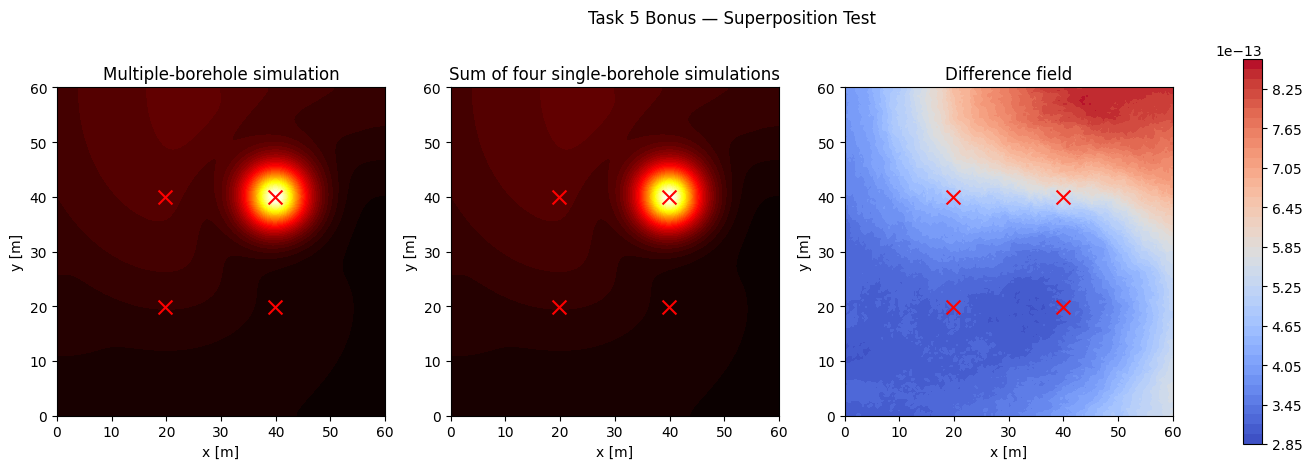

In [ ]:
# ============================================================
# PLOT SUPERPOSITION TEST
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fields = [
    ("Multiple-borehole simulation", T_multiple),
    ("Sum of four single-borehole simulations", T_superposition),
    ("Difference field", difference_field)
]

vmin = min(np.min(T_multiple), np.min(T_superposition))
vmax = max(np.max(T_multiple), np.max(T_superposition))

for ax, (title, field) in zip(axes, fields):

    if title == "Difference field":
        contour = ax.contourf(X, Y, field, levels=50, cmap="coolwarm")
    else:
        contour = ax.contourf(
            X, Y, field,
            levels=50,
            cmap="hot",
            vmin=vmin,
            vmax=vmax
        )

    for bx, by in boreholes:
        ax.scatter(bx, by, color="red", marker="x", s=100)

    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")

fig.colorbar(contour, ax=axes.ravel().tolist())
plt.suptitle("Task 5 Bonus — Superposition Test")
plt.show()